### The goal of this notebook is to test various simulation methods, as well as to cluster final conformations to compare methods.

In [21]:
import numpy as np  # Numerical operations and array manipulations
import matplotlib.pyplot as plt  # Plotting and data visualization
import pandas as pd  # Data structures for handling data (e.g., DataFrame)
import visualization_functions as vis # our functions for visualization
import sim_methods as sim # our functions for simulation

def averageEnergies(arr, mode='mean'):
    max_len = max(len(a) for a in arr)

    padded = np.full((len(arr), max_len), np.nan)

    for j, a in enumerate(arr):
        padded[j, :len(a)] = a

    if mode == 'mean':
        means = np.nanmean(padded, axis=0)
    elif mode == 'median':
        means = np.nanmedian(padded, axis=0)
    else:
        return

    return means

def averageDeltaEnergies(arr, mode='mean'):
    diffs = [np.diff(a) for a in arr]

    max_len = max(len(d) for d in diffs)

    padded = np.full((len(diffs), max_len), np.nan)

    for j, d in enumerate(diffs):
        padded[j, :len(d)] = d

    if mode == 'mean':
        means = np.nanmean(padded, axis=0)
    elif mode == 'median':
        means = np.nanmedian(padded, axis=0)
    else:
        return
    
    return means

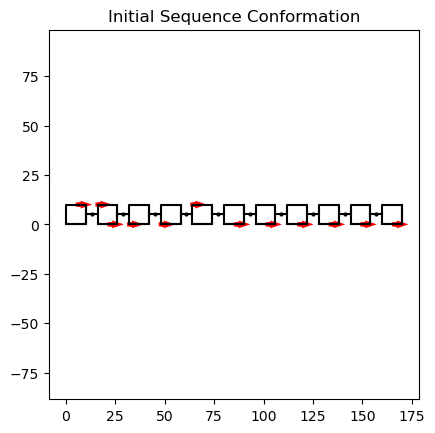

In [2]:
shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
          'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}

hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)

vis.shapeplots(shape_arr, linelist, hinge_loc, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

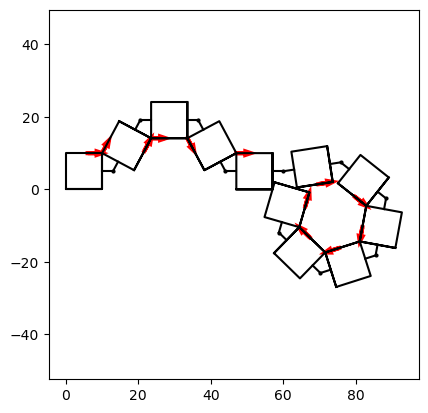

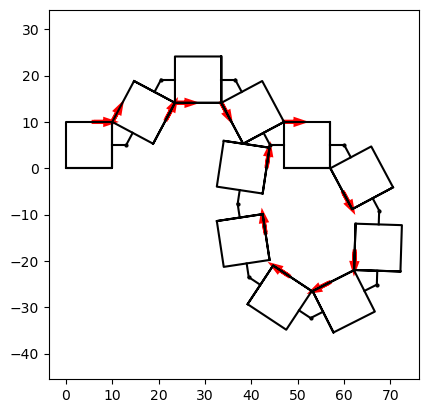

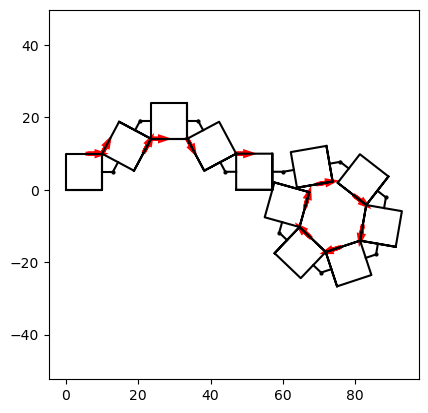

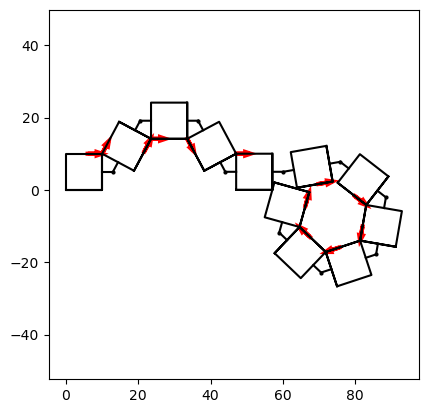

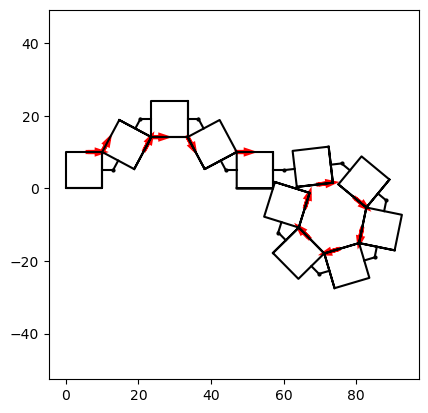

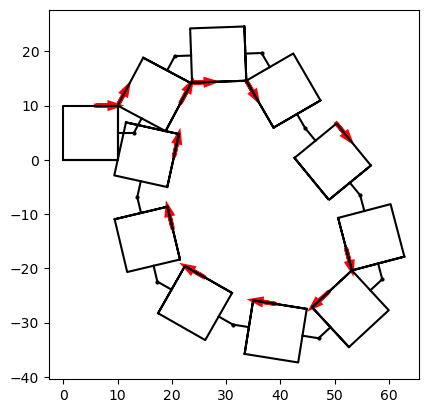

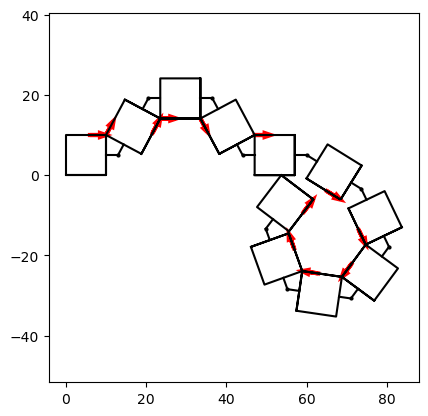

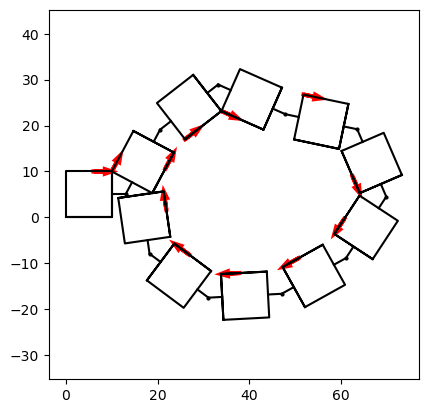

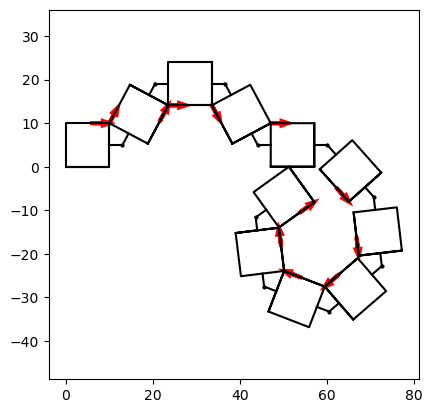

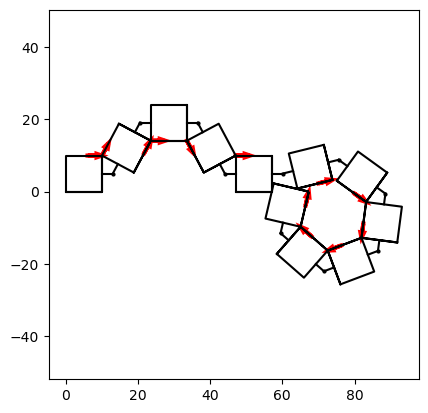

In [27]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 10 # number of simulations
final_hinges, final_es = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False, plot=True)

### Running each method 1000 times and clustering to compare results

#### Greedy Descent

In [4]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 1000 # number of simulations
final_hinges_gd, final_es_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

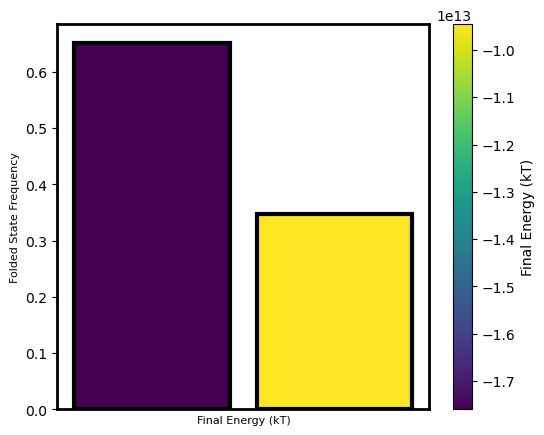

In [6]:
cluster_max_gd = 6
states_gd = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber_gd = vis.cluster_num(final_hinges_gd,cluster_max_gd,states_gd, Plot = False)
clustercenters_gd, cluster_labels_gd, clusternumber_gd = vis.min_cluster_centers(final_hinges_gd, clusternumber_gd, final_es_gd)
clusternumbers_gd, cluster_count_gd, cluster_prob_gd, energies_gd, ordered_centers_gd, all_stds_gd = vis.cluster_stats(final_hinges_gd, clusternumber_gd, clustercenters_gd, cluster_labels_gd,
                                                                                                    final_es_gd, plot=True)

#### Monte Carlo

In [6]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 1000 # number of simulations
final_hinges_mc, final_es_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

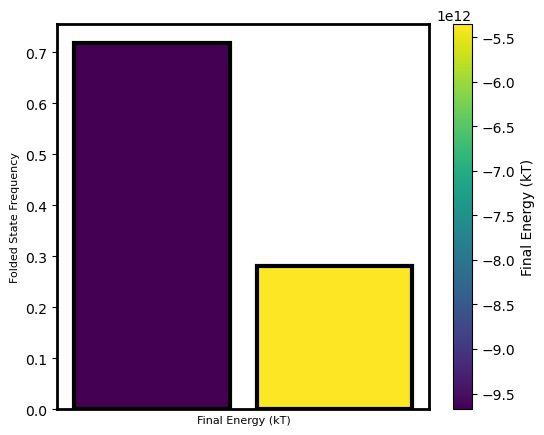

In [5]:
cluster_max_mc = 6
states_mc = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber_mc = vis.cluster_num(final_hinges_mc,cluster_max_mc,states_mc, Plot = False)
clustercenters_mc, cluster_labels_mc, clusternumber_mc = vis.min_cluster_centers(final_hinges_mc, clusternumber_mc, final_es_mc)
clusternumbers_mc, cluster_count_mc, cluster_prob_mc, energies_mc, ordered_centers_mc, all_stds_mc = vis.cluster_stats(final_hinges_mc, clusternumber_mc, clustercenters_mc, cluster_labels_mc,
                                                                                                    final_es_mc, plot=True)

#### Weighted Sync

In [8]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 1000 # number of simulations
final_hinges_ws, final_es_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

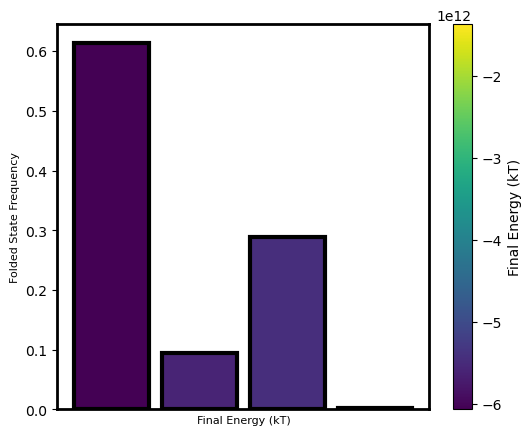

In [4]:
cluster_max_ws = 6
states_ws = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber_ws = vis.cluster_num(final_hinges_ws,cluster_max_ws,states_ws, Plot = False)
clustercenters_ws, cluster_labels_ws, clusternumber_ws = vis.min_cluster_centers(final_hinges_ws, clusternumber_ws, final_es_ws)
clusternumbers_ws, cluster_count_ws, cluster_prob_ws, energies_ws, ordered_centers_ws, all_stds_ws = vis.cluster_stats(final_hinges_ws, clusternumber_ws, clustercenters_ws, cluster_labels_ws,
                                                                                                    final_es_ws, plot=True)

### Checking structures of clusters

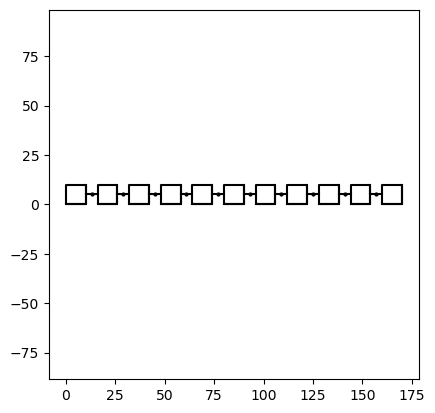

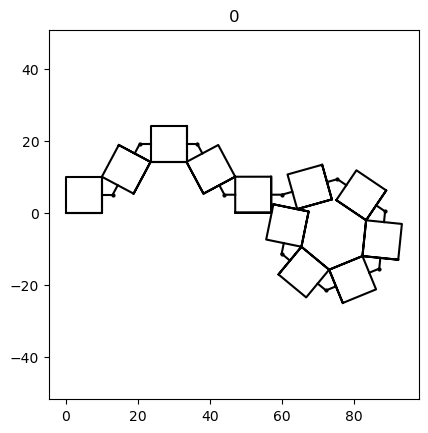

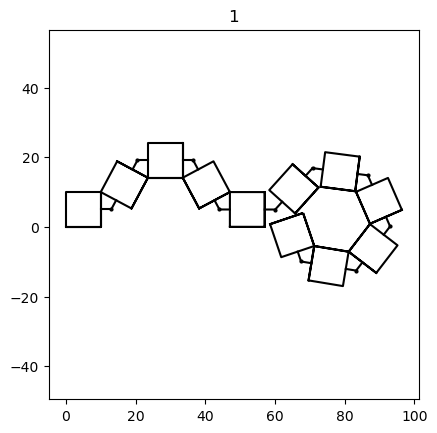

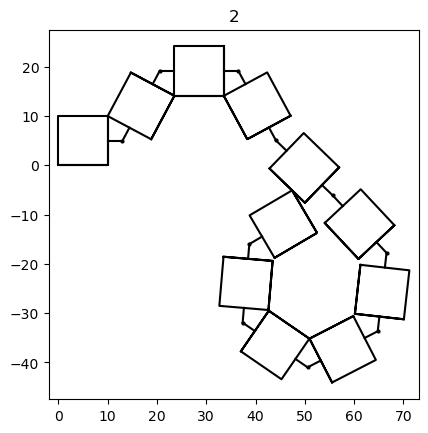

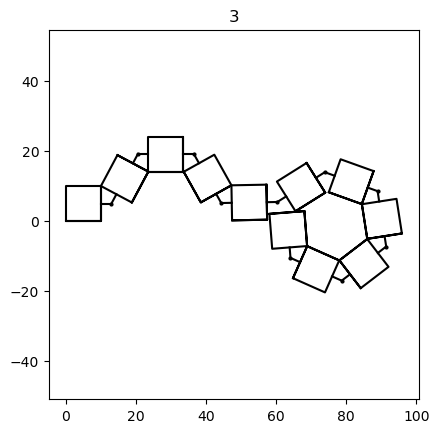

In [37]:
hinges=[0,1,2,3,4,5,6,7,8,9]
vis.show_probable_structures(hinges, shapes, clustercenters_ws)

### Saving of data

In [53]:
# save all data
np.save("final_hinges_gd",final_hinges_gd)
np.save("final_hinges_mc",final_hinges_mc)
np.save("final_hinges_ws",final_hinges_ws)

np.save("final_es_gd", final_es_gd)
np.save("final_es_mc", final_es_mc)
np.save("final_es_ws", final_es_ws)

In [3]:
final_hinges_gd = np.load("final_hinges_gd.npy")
final_hinges_mc = np.load("final_hinges_mc.npy")
final_hinges_ws = np.load("final_hinges_ws.npy")

final_es_gd = np.load("final_es_gd.npy")
final_es_mc = np.load("final_es_mc.npy")
final_es_ws = np.load("final_es_ws.npy")

### Saving energy vs. time step for single runs to compare:

In [ ]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 3 # number of simulations
final_hinges_gd, final_es_gd, energies_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

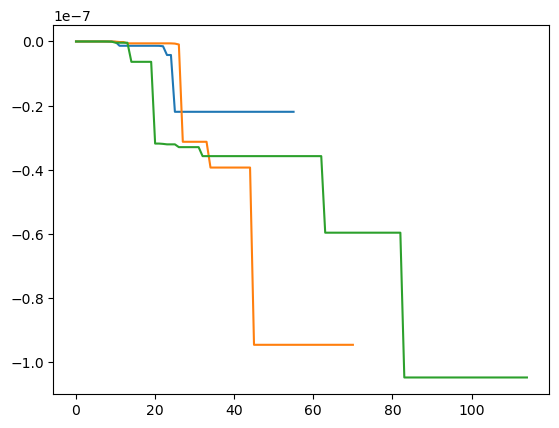

In [ ]:
for i in range(len(energies_gd)):
    plt.plot(energies_gd[i])


In [ ]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 3 # number of simulations
final_hinges_mc, final_es_mc, energies_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

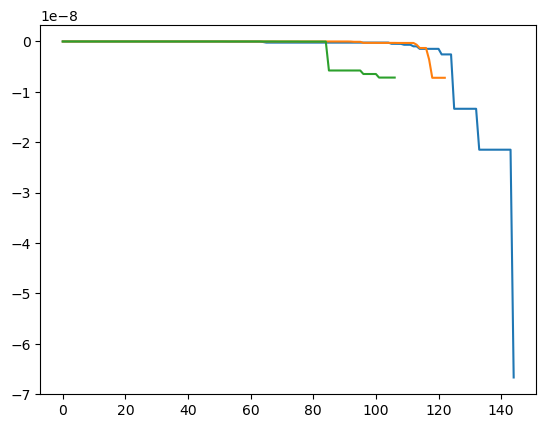

In [ ]:
for i in range(len(energies_mc)):
    plt.plot(energies_mc[i])


In [ ]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 3 # number of simulations
final_hinges_ws, final_es_ws, energies_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

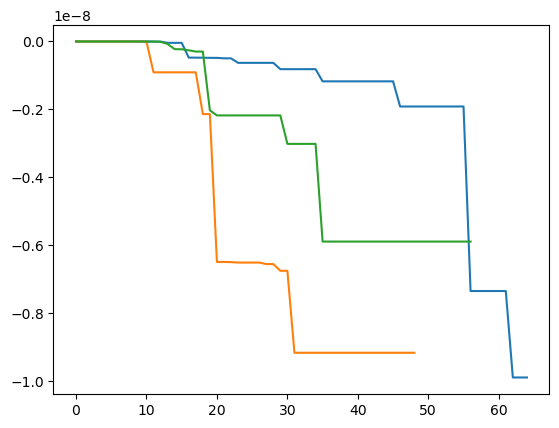

In [ ]:
for i in range(len(energies_ws)):
    plt.plot(energies_ws[i])


In [3]:
# sim many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
nsim = 100 # number of simulations
final_hinges_gd, final_es_gd, energies_gd = sim.sim_many(nsim, 'greedy descent',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)
final_hinges_mc, final_es_mc, energies_mc = sim.sim_many(nsim, 'monte carlo',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)
final_hinges_ws, final_es_ws, energies_ws = sim.sim_many(nsim, 'weighted sync',patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=False)

In [4]:
# save energies
# np.save("Energies/energies_gd_1000", energies_gd)
# np.save("Energies/energies_mc_1000", energies_mc)
# np.save("Energies/energies_ws_1000_oldnorm", energies_ws)

np.save("Energies/final_es_gd_100", final_es_gd)
np.save("Energies/final_es_mc_100", final_es_mc)
np.save("Energies/final_es_ws_100", final_es_ws)

np.save("Energies/final_hinges_gd_100", final_hinges_gd)
np.save("Energies/final_hinges_mc_100", final_hinges_mc)
np.save("Energies/final_hinges_ws_100", final_hinges_ws)

In [36]:
# load energies
energies_gd = np.load("Energies/energies_gd_1000.npy", allow_pickle=True)
energies_mc = np.load("Energies/energies_mc_1000.npy", allow_pickle=True)
energies_ws = np.load("Energies/energies_ws_1000.npy", allow_pickle=True)

Text(0, 0.5, 'Energy (J)')

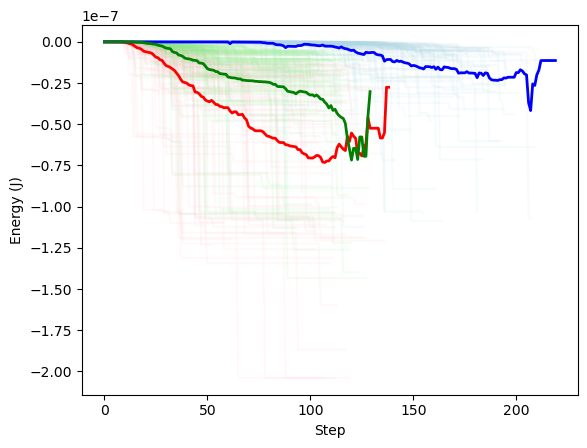

In [12]:
for i in range(len(energies_gd)):
    plt.plot(energies_gd[i],c='pink',alpha=0.1)

for i in range(len(energies_mc)):
    plt.plot(energies_mc[i],c='lightblue', alpha=0.1)

for i in range(len(energies_ws)):
    plt.plot(energies_ws[i],c='lightgreen', alpha = 0.1)

plt.plot(averageEnergies(energies_gd),c='r',lw=2)
plt.plot(averageEnergies(energies_mc),c='b',lw=2)
plt.plot(averageEnergies(energies_ws),c='g',lw=2)

plt.xlabel("Step")
plt.ylabel("Energy (J)")

Text(0, 0.5, 'Energy (J)')

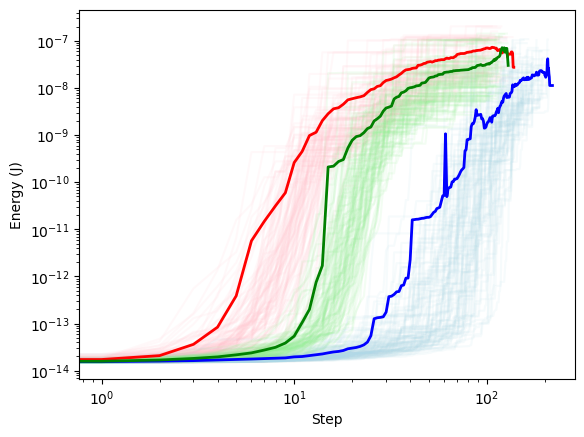

In [7]:
for i in range(len(energies_gd)):
    plt.loglog(np.abs(energies_gd[i]),c='pink',alpha=0.1)

for i in range(len(energies_mc)):
    plt.loglog(np.abs(energies_mc[i]),c='lightblue',alpha=0.1)

for i in range(len(energies_ws)):
    plt.loglog(np.abs(energies_ws[i]),c='lightgreen',alpha=0.1)

plt.loglog(np.abs(averageEnergies(energies_gd)),c='r',lw=2)
plt.loglog(np.abs(averageEnergies(energies_mc)),c='b',lw=2)
plt.loglog(np.abs(averageEnergies(energies_ws)),c='g',lw=2)

plt.xlabel("Step")
plt.ylabel("Energy (J)")

Text(0, 0.5, 'Energy (J)')

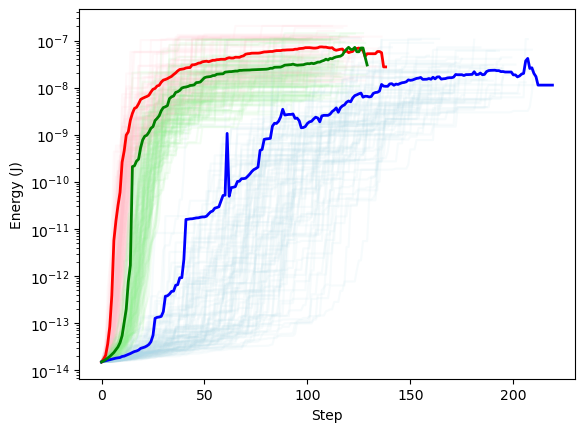

In [8]:
for i in range(len(energies_gd)):
    plt.semilogy(np.abs(energies_gd[i]),c='pink',alpha=0.1)

for i in range(len(energies_mc)):
    plt.semilogy(np.abs(energies_mc[i]),c='lightblue',alpha=0.1)

for i in range(len(energies_ws)):
    plt.semilogy(np.abs(energies_ws[i]),c='lightgreen',alpha=0.1)

plt.semilogy(np.abs(averageEnergies(energies_gd)),c='r',lw=2)
plt.semilogy(np.abs(averageEnergies(energies_mc)),c='b',lw=2)
plt.semilogy(np.abs(averageEnergies(energies_ws)),c='g',lw=2)

plt.xlabel("Step")
plt.ylabel("Energy (J)")

Text(0.5, 0, 'Energy')

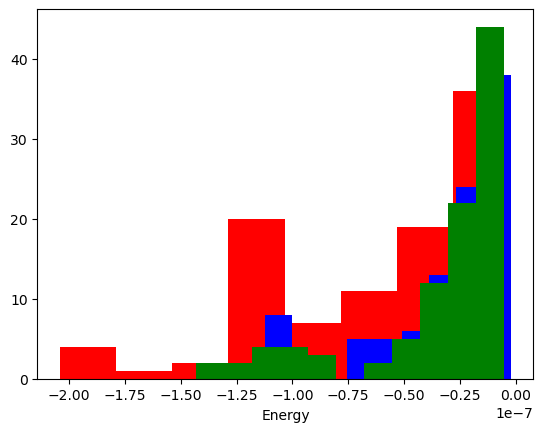

In [9]:
plt.hist(final_es_gd,bins='auto',color="red")
plt.hist(final_es_mc,bins='auto',color="blue")
plt.hist(final_es_ws,bins='auto',color="green")

plt.xlabel("Energy")

Text(0, 0.5, '$\\Delta$E (J)')

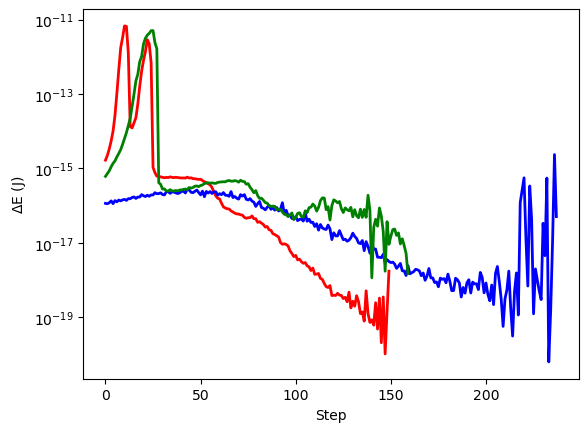

In [ ]:
# delta energy vs. time

# for i in range(len(energies_gd)):
#     plt.plot(np.diff(energies_gd[i]),c='pink',alpha=0.1)

# for i in range(len(energies_mc)):
#     plt.plot(np.diff(energies_mc[i]),c='lightblue', alpha=0.1)

# for i in range(len(energies_ws)):
#     plt.plot(np.diff(energies_ws[i]),c='lightgreen', alpha = 0.1)

plt.semilogy(abs(averageDeltaEnergies(energies_gd, mode='median')),c='r',lw=2)
plt.semilogy(abs(averageDeltaEnergies(energies_mc, mode='median')),c='b',lw=2)
plt.semilogy(abs(averageDeltaEnergies(energies_ws, mode='median')),c='g',lw=2)

# plt.ylim(-0.1E-10,0)
# plt.xlim(0,100)

plt.xlabel("Step")
plt.ylabel("$\Delta$E (J)")

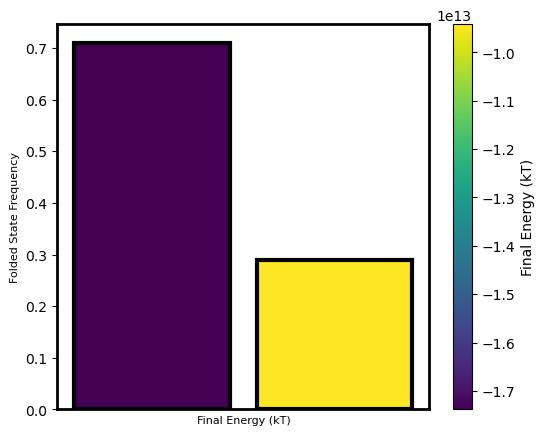

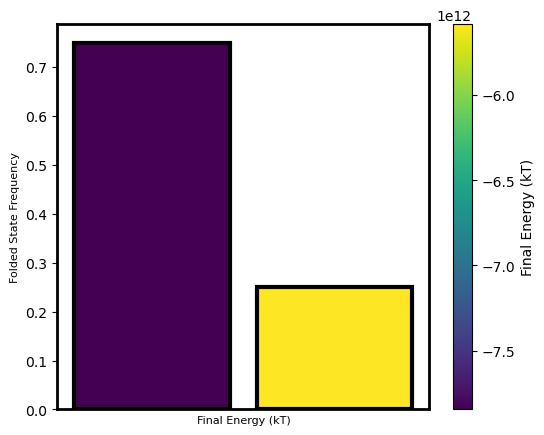

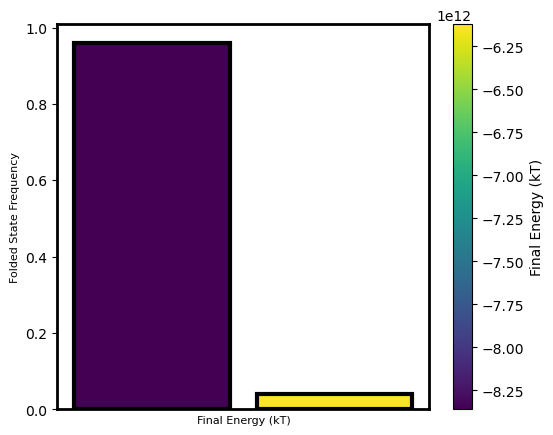

In [10]:
cluster_max = 6
states = 10 #A cluster parameter that allows the KMeans clustering to try out different initial states for better optimization
clusternumber_gd = vis.cluster_num(final_hinges_gd,cluster_max,states, Plot = False)
clustercenters_gd, cluster_labels_gd, clusternumber_gd = vis.min_cluster_centers(final_hinges_gd, clusternumber_gd, final_es_gd)
clusternumbers_gd, cluster_count_gd, cluster_prob_gd, cluster_energies_gd, ordered_centers_gd, all_stds_gd = vis.cluster_stats(final_hinges_gd, clusternumber_gd, clustercenters_gd, cluster_labels_gd,
                                                                                                    final_es_gd, plot=True)

clusternumber_mc = vis.cluster_num(final_hinges_mc,cluster_max,states, Plot = False)
clustercenters_mc, cluster_labels_mc, clusternumber_mc = vis.min_cluster_centers(final_hinges_mc, clusternumber_mc, final_es_mc)
clusternumbers_mc, cluster_count_mc, cluster_prob_mc, cluster_energies_mc, ordered_centers_mc, all_stds_mc = vis.cluster_stats(final_hinges_mc, clusternumber_mc, clustercenters_mc, cluster_labels_mc,
                                                                                                    final_es_mc, plot=True)

clusternumber_ws = vis.cluster_num(final_hinges_ws,cluster_max,states, Plot = False)
clustercenters_ws, cluster_labels_ws, clusternumber_ws = vis.min_cluster_centers(final_hinges_ws, clusternumber_ws, final_es_ws)
clusternumbers_ws, cluster_count_ws, cluster_prob_ws, cluster_energies_ws, ordered_centers_ws, all_stds_ws = vis.cluster_stats(final_hinges_ws, clusternumber_ws, clustercenters_ws, cluster_labels_ws,
                                                                                                    final_es_ws, plot=True)

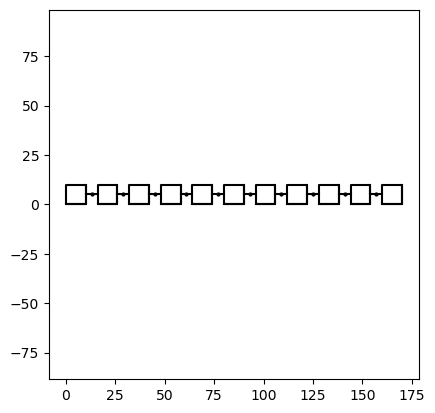

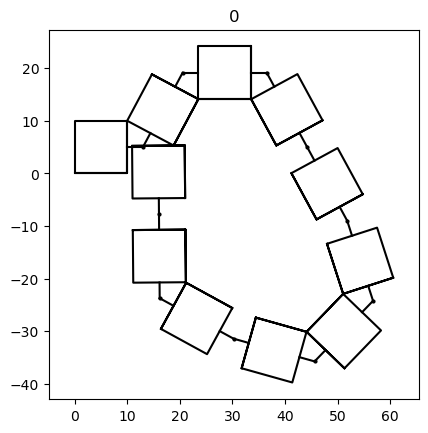

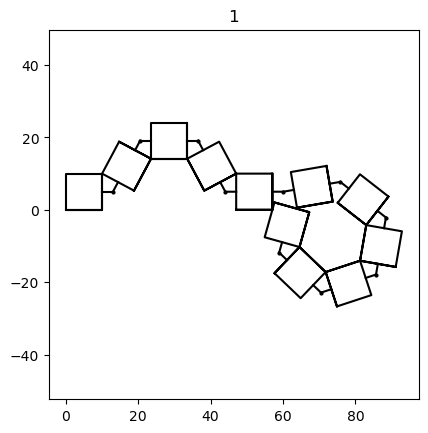

In [11]:
hinges=[0,1,2,3,4,5,6,7,8,9]
vis.show_probable_structures(hinges, shapes, clustercenters_gd)

### Testing for the ending of GD vs MC and WS

In [3]:
# run MC and WS down to some final populations
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
patch_arr_mc, shape_arr_mc, hinge_vec_mc, hinge_loc_mc, current_energy_mc, energy_mc = sim.simulate_monteCarlo(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter)
patch_arr_ws, shape_arr_ws, hinge_vec_ws, hinge_loc_ws, current_energy_ws, energy_ws = sim.simulate_weightedSync(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter)
        

MC:  -1.8330258032241292e-08
WS:  -1.2542130495025324e-08


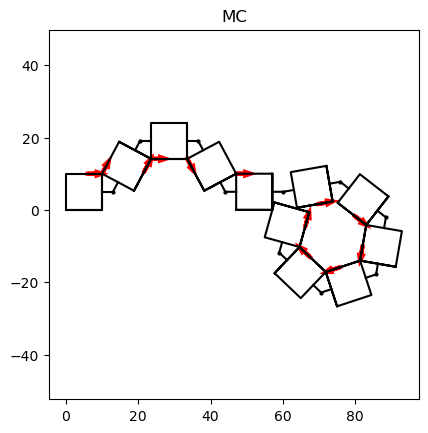

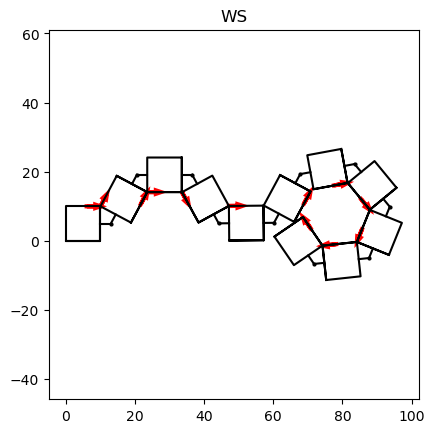

In [4]:
# print out the energies and plot the shapes
print("MC: ", current_energy_mc)
print("WS: ", current_energy_ws)

vis.shapeplots(shape_arr_mc, linelist, hinge_loc_mc, blocking = False, title = 'MC', show = True, bounds = '', mag_vecs = patch_arr_mc)
vis.shapeplots(shape_arr_ws, linelist, hinge_loc_ws, blocking = False, title = 'WS', show = True, bounds = '', mag_vecs = patch_arr_ws)

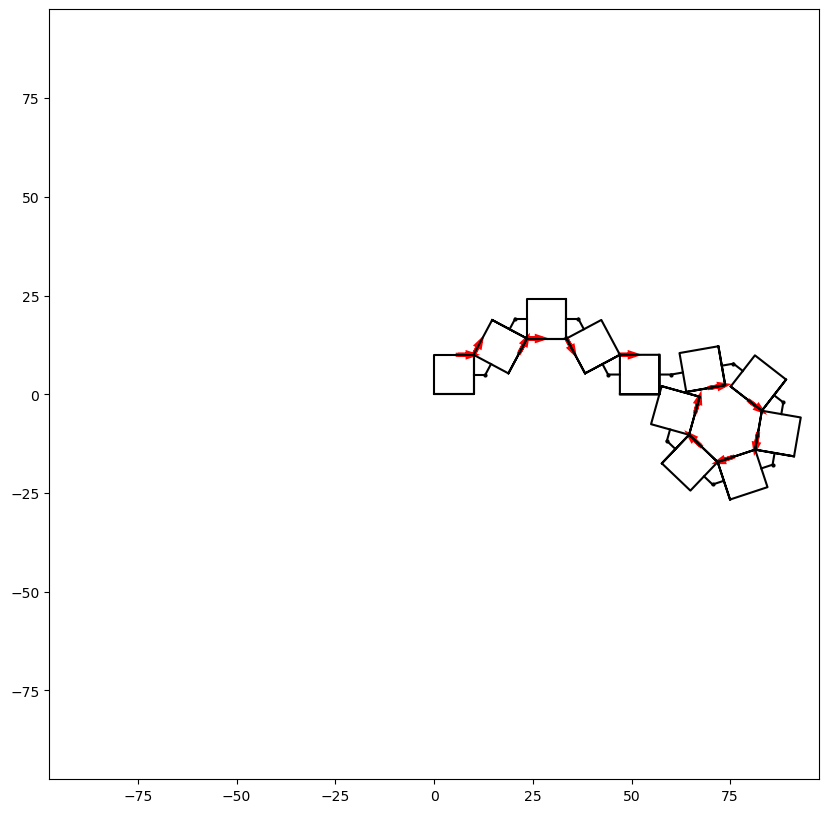

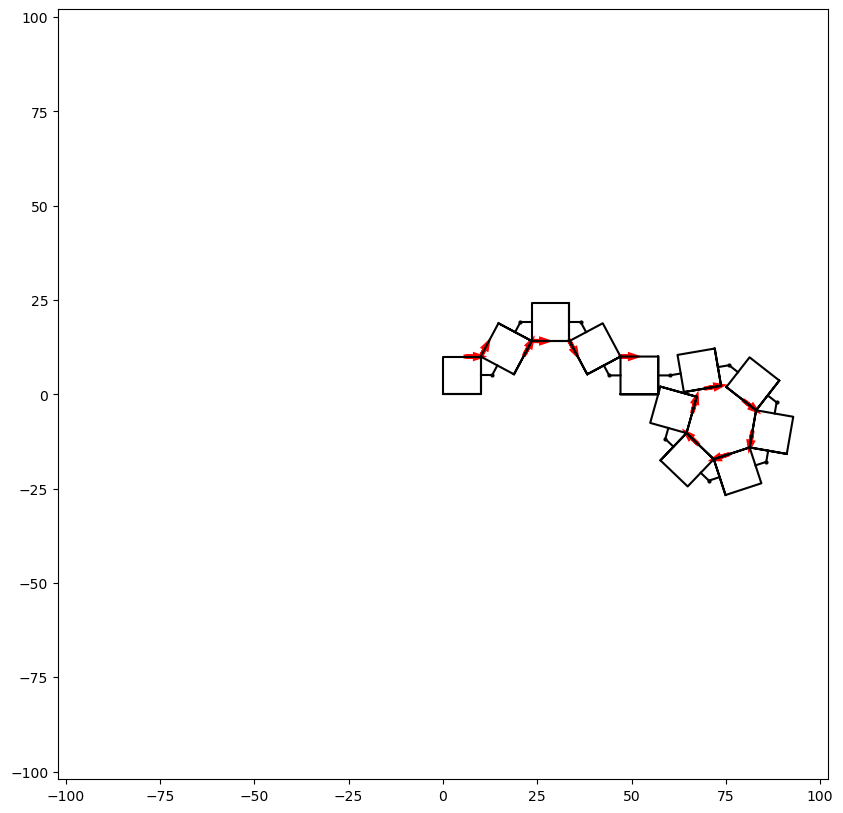

In [7]:
patch_arr_gdmc, shape_arr_gdmc, hinge_vec_gdmc, hinge_loc_gdmc, current_energy_gdmc, energy_gdmc = sim.simulate_greedyDescent(patch_arr_mc,shape_arr_mc,linelist,hinge_vec_mc, hinge_loc_mc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, sim_num=1, ani_folder='tests')
patch_arr_gdws, shape_arr_gdws, hinge_vec_gdws, hinge_loc_gdws, current_energy_gdws, energy_gdws = sim.simulate_greedyDescent(patch_arr_ws,shape_arr_ws,linelist,hinge_vec_ws, hinge_loc_ws, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, sim_num=2, ani_folder='tests')

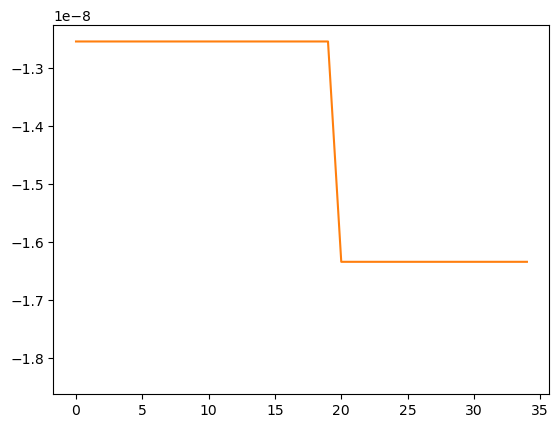

In [9]:
plt.plot(energy_gdmc)
plt.plot(energy_gdws)

/Users/dylanmccuskey/PythonProjects/MagneticActuators/Git/Magnetic-actuator-simulation/sim_methods.py:187: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10,10))


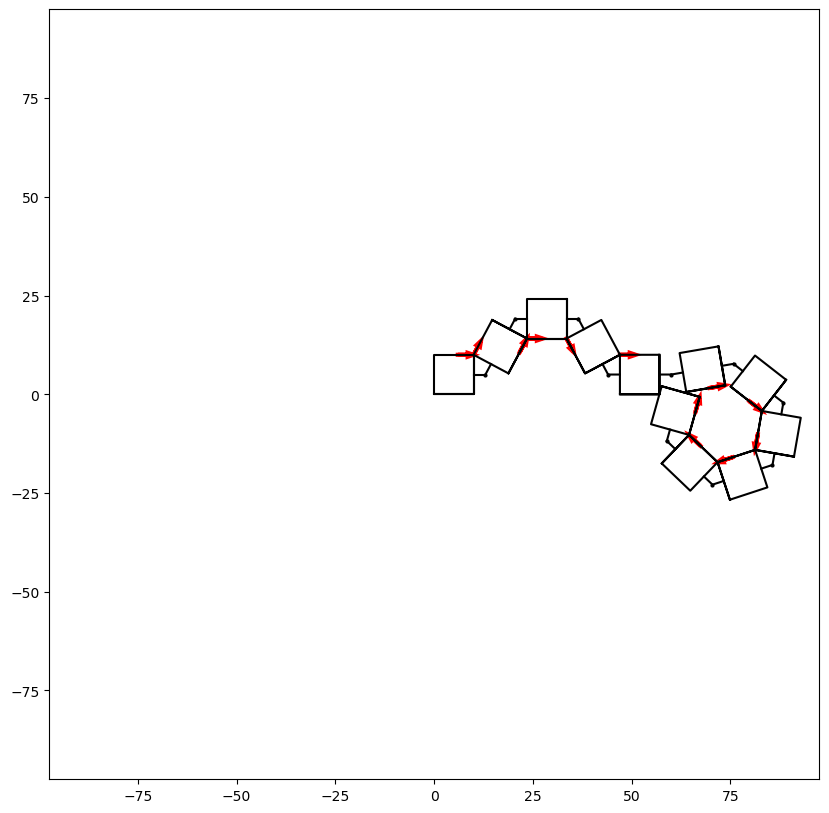

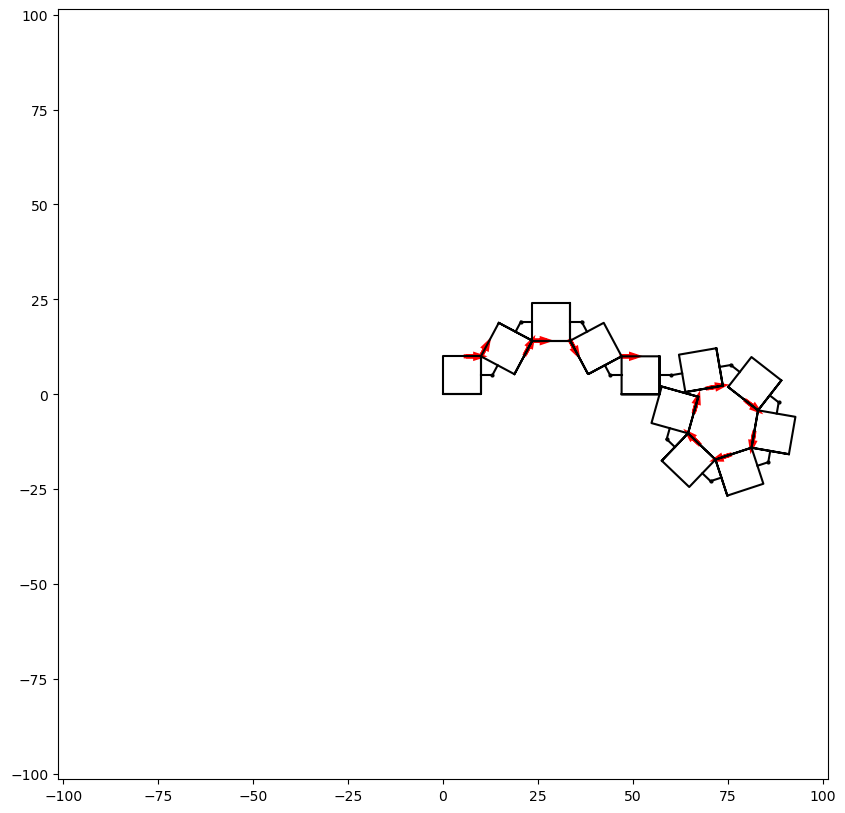

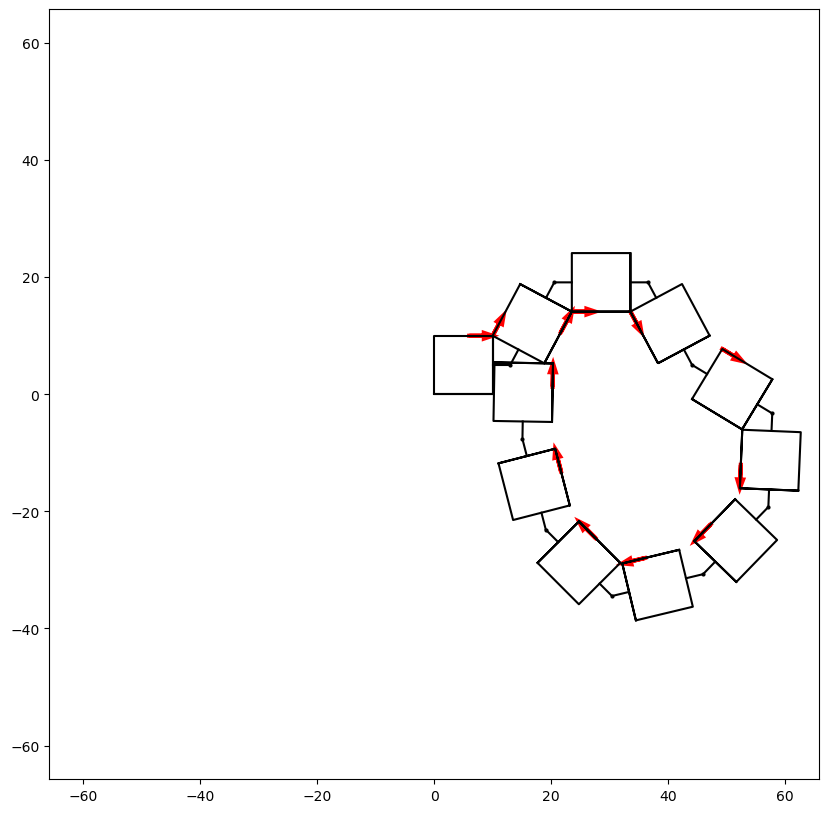

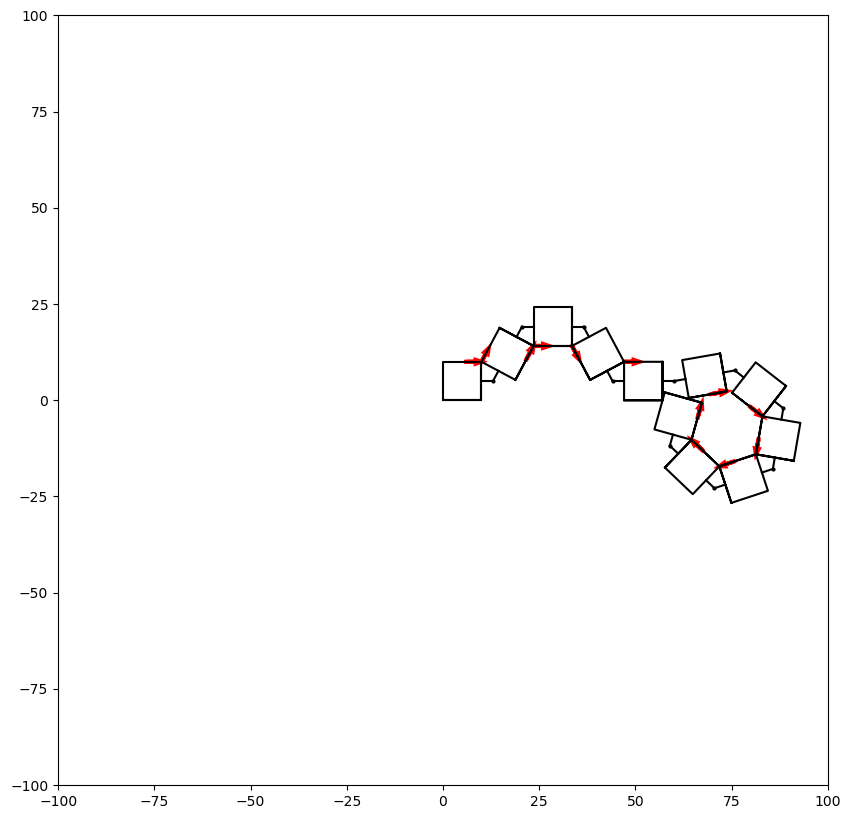

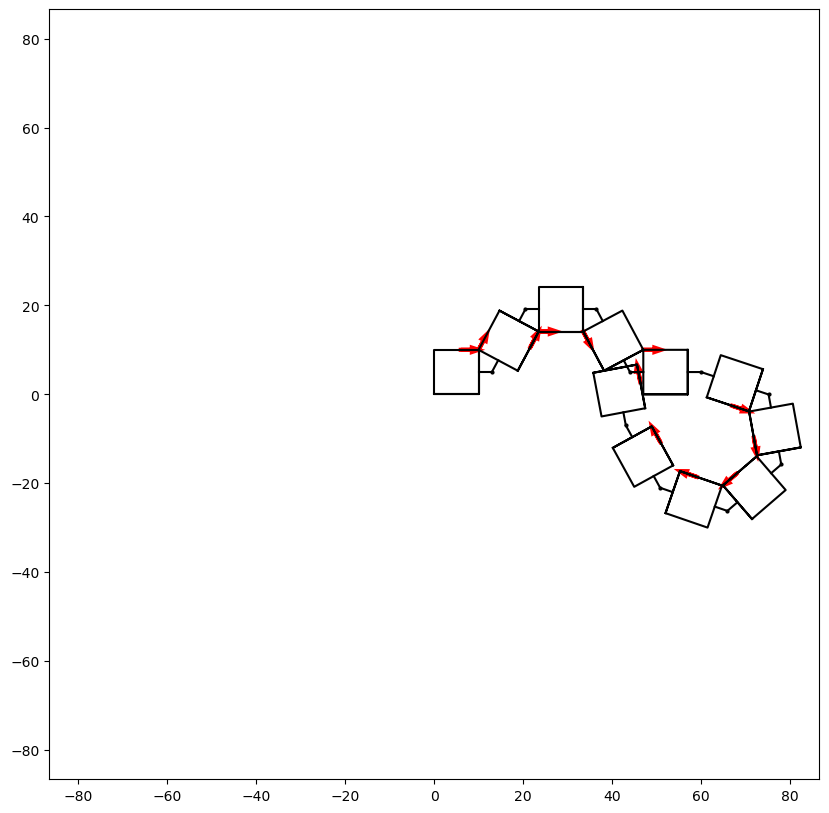

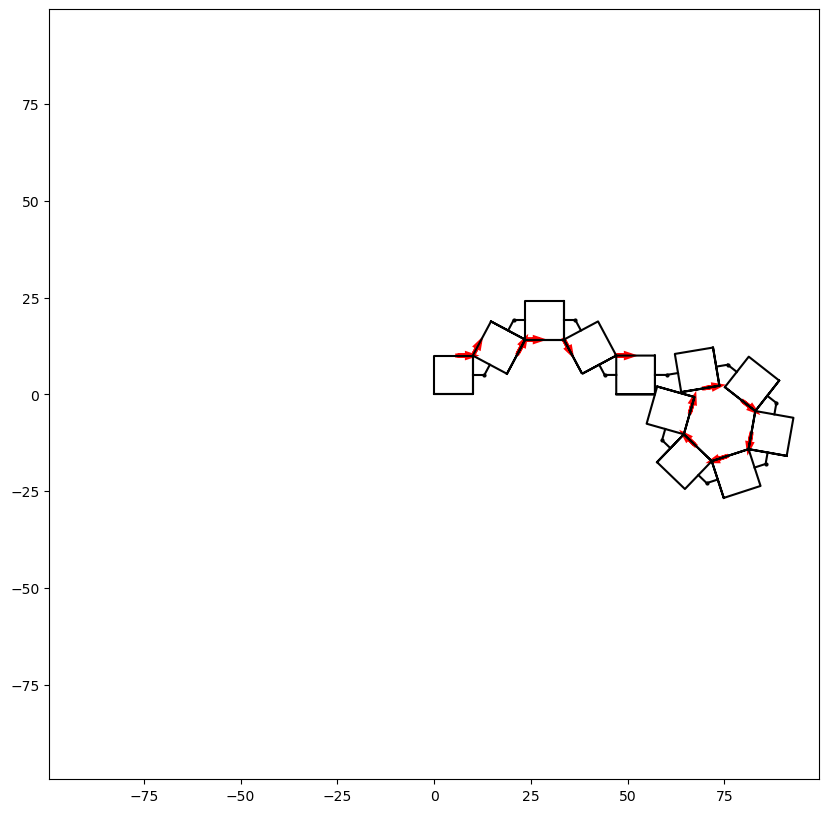

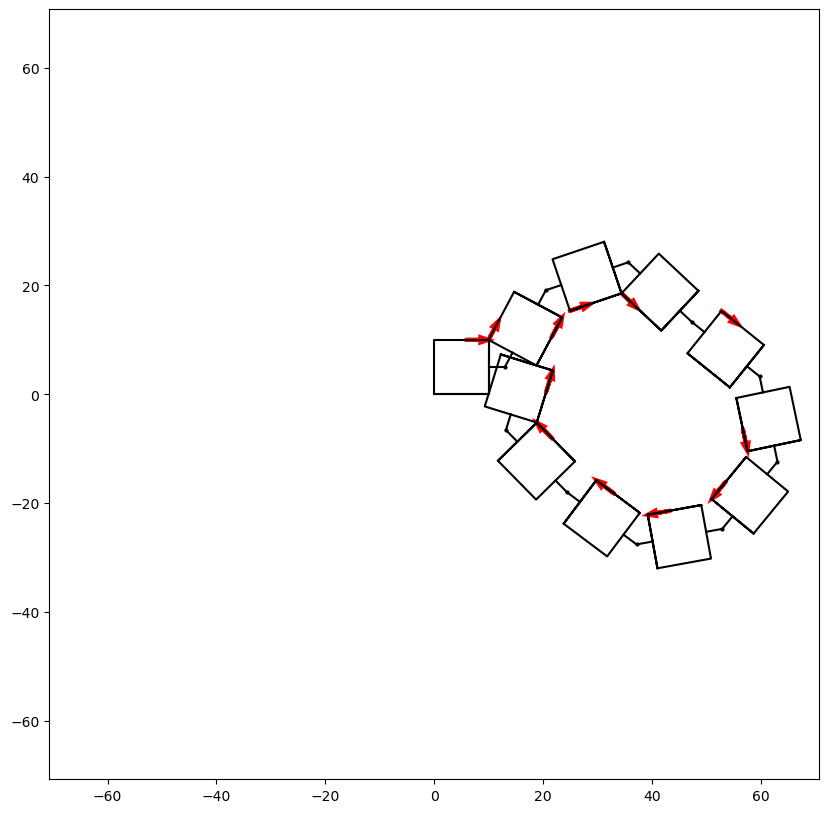

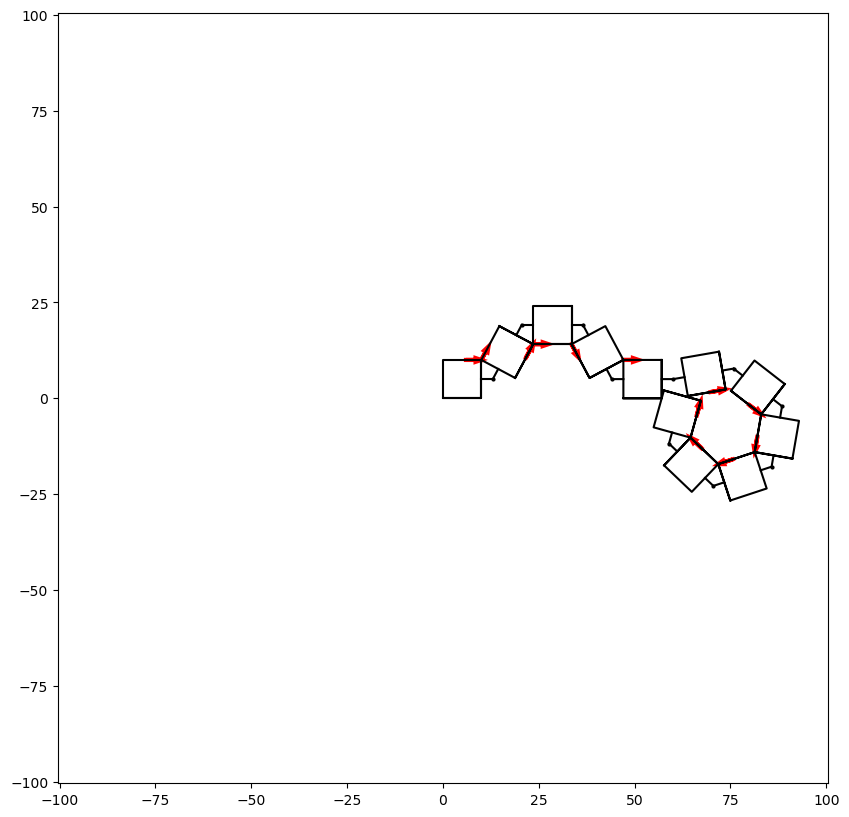

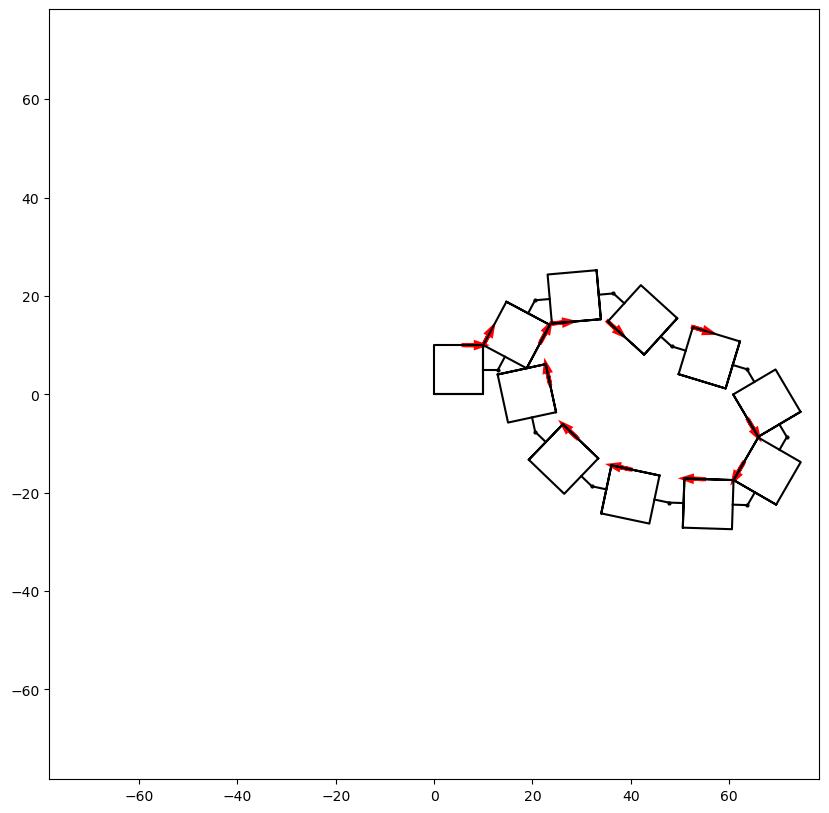

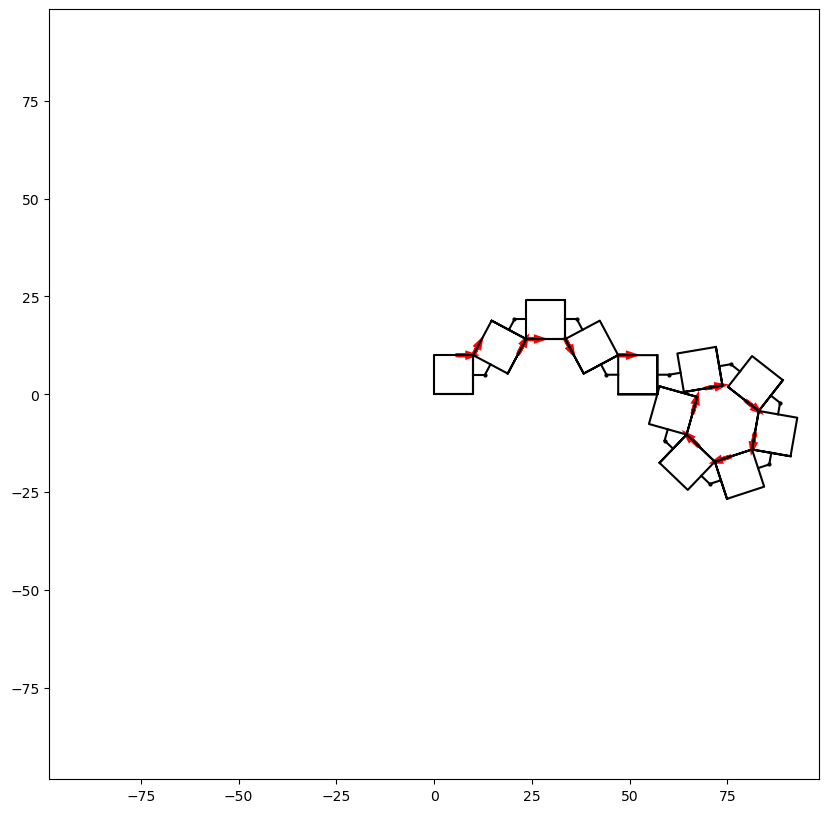

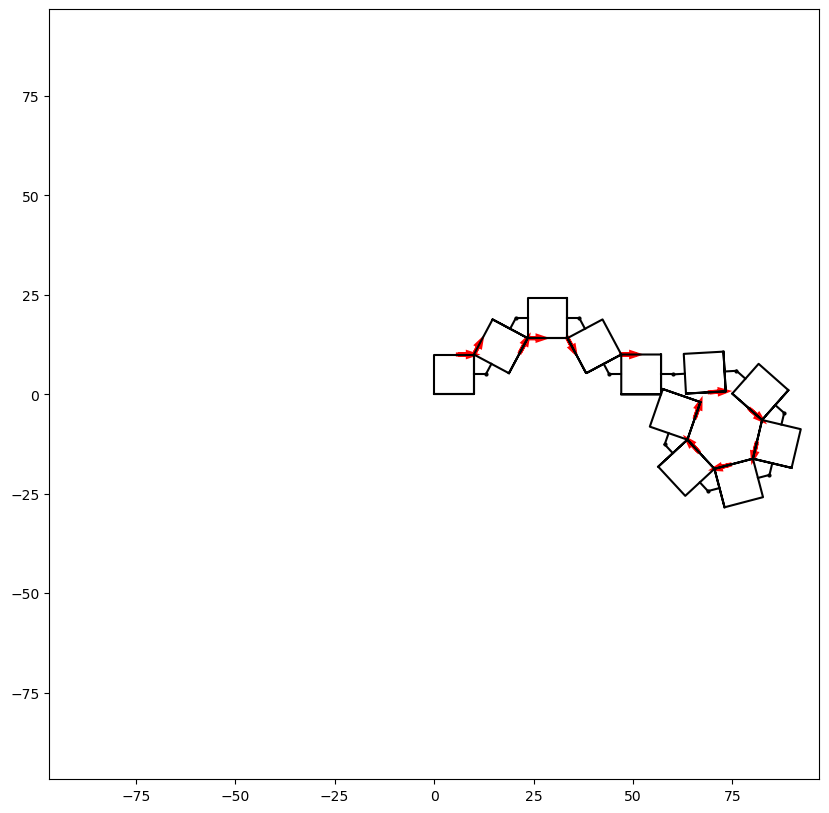

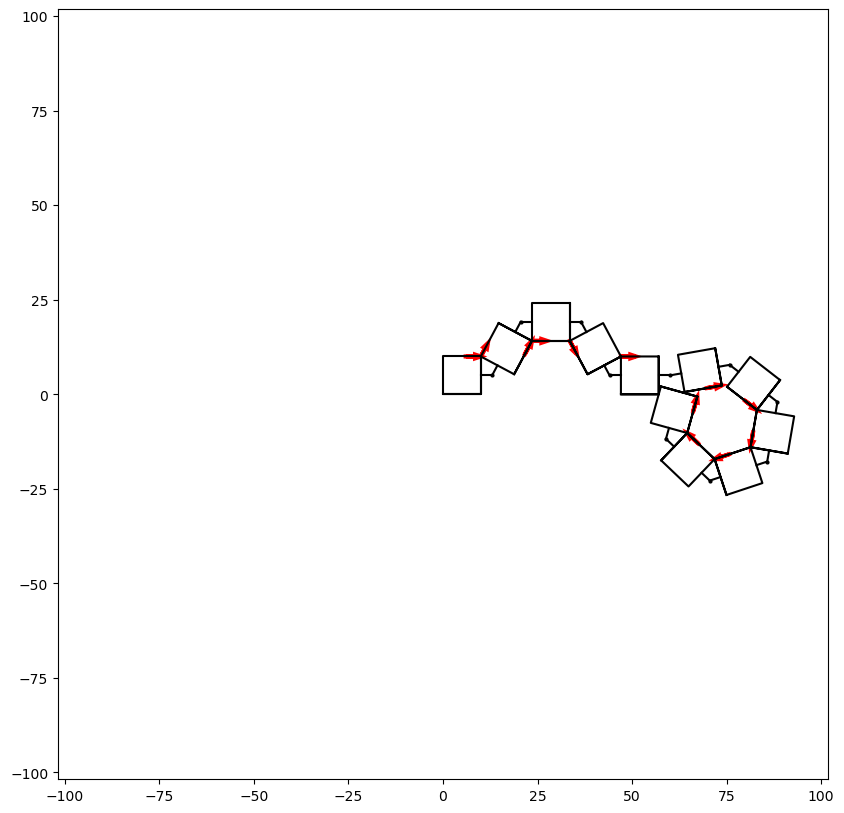

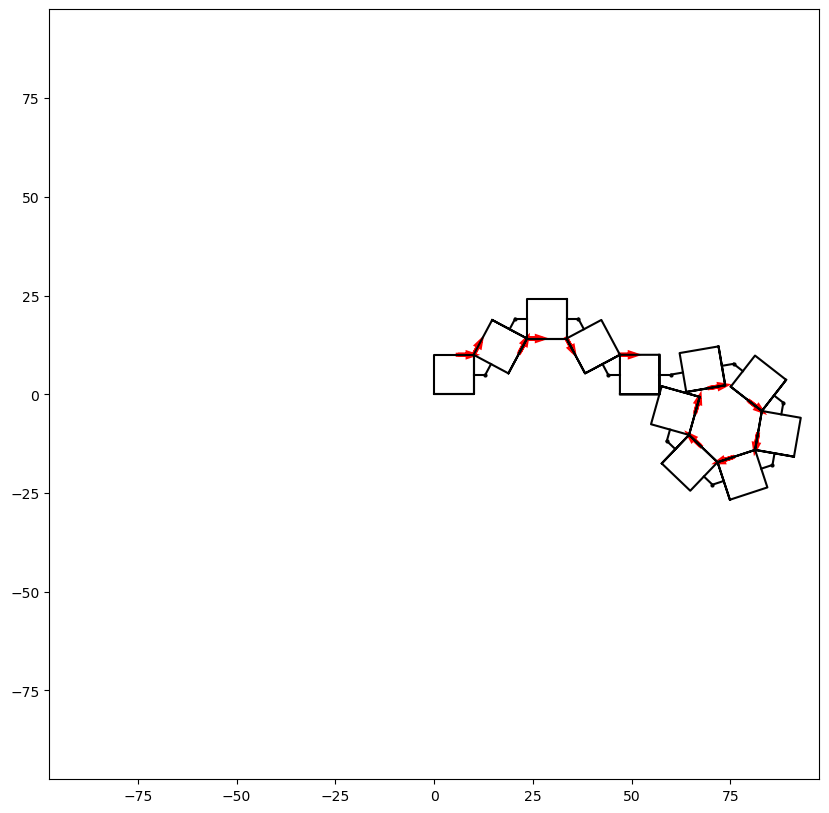

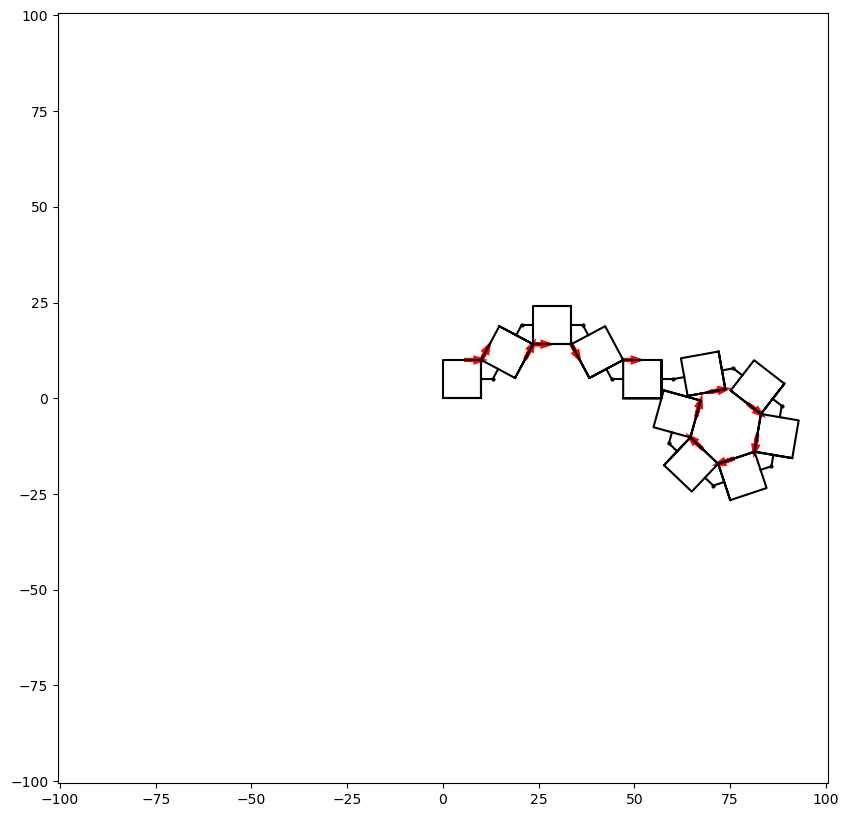

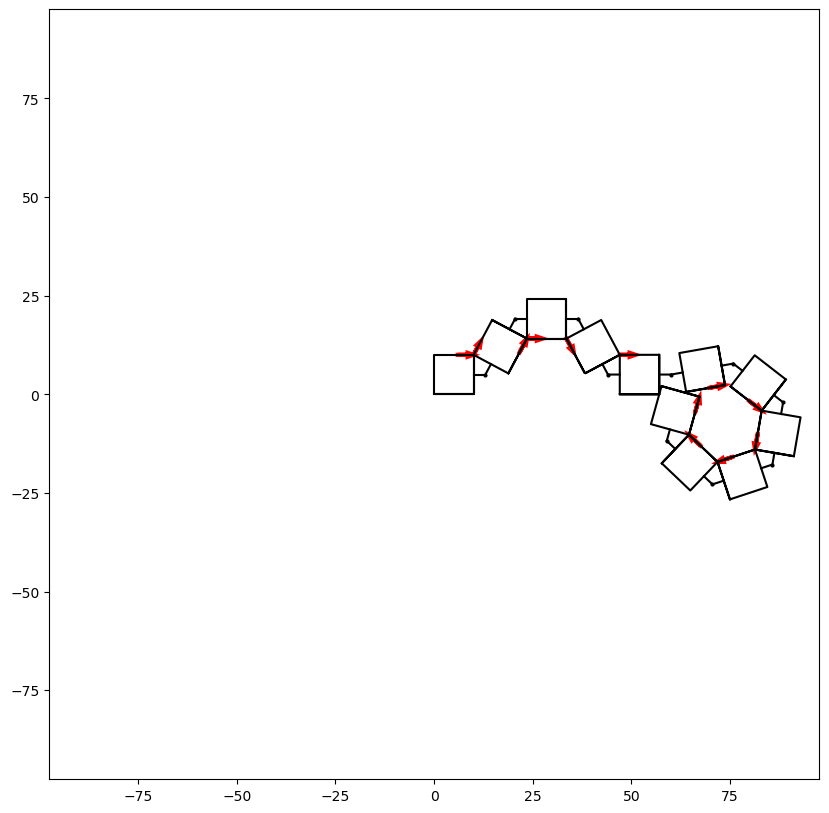

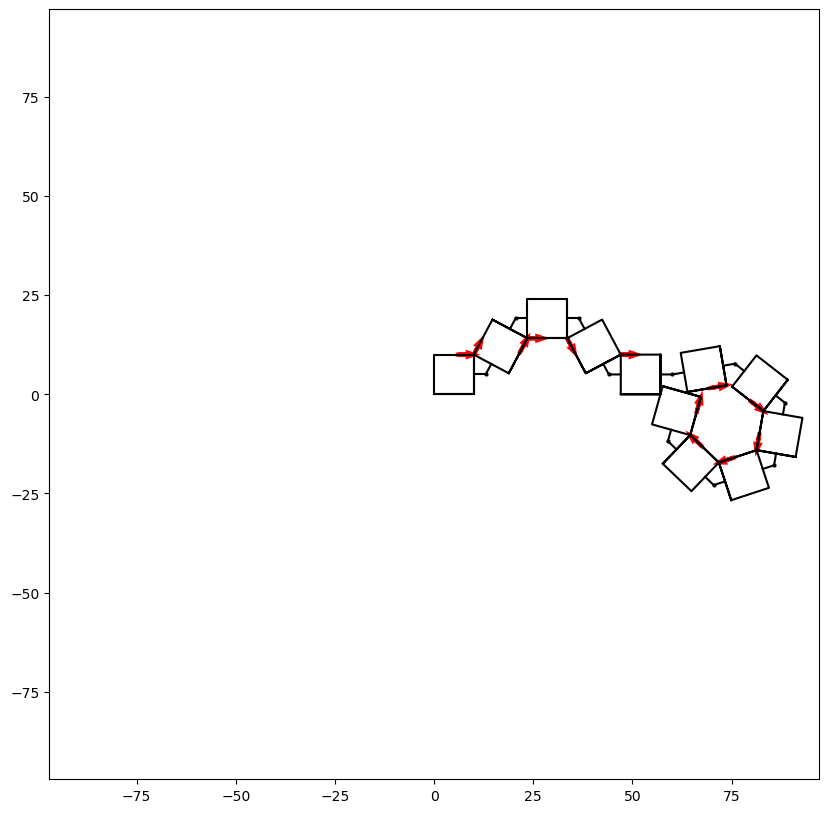

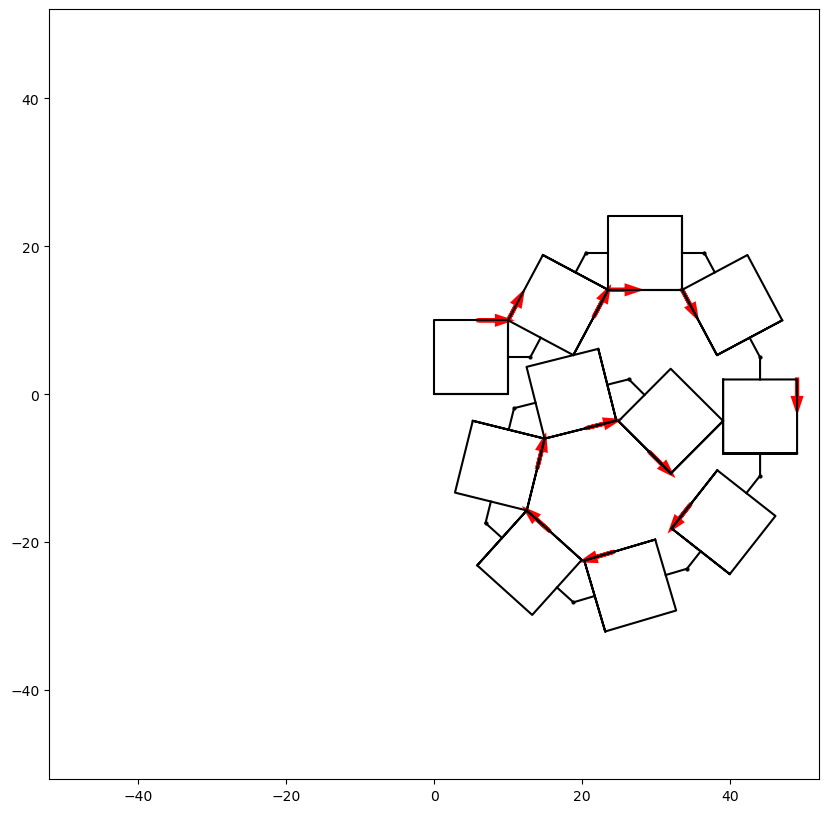

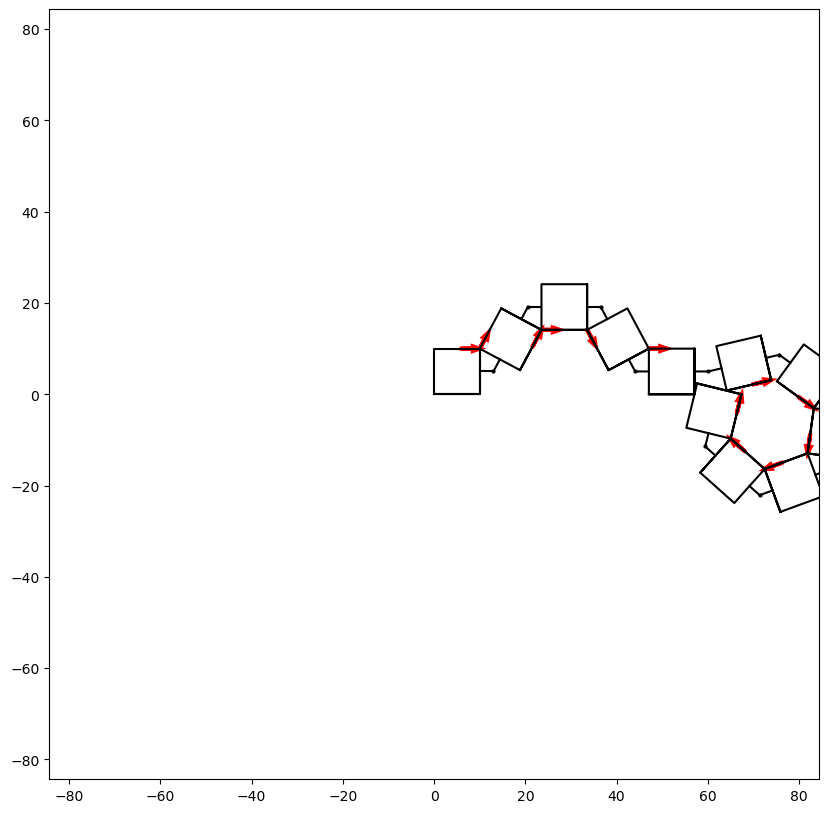

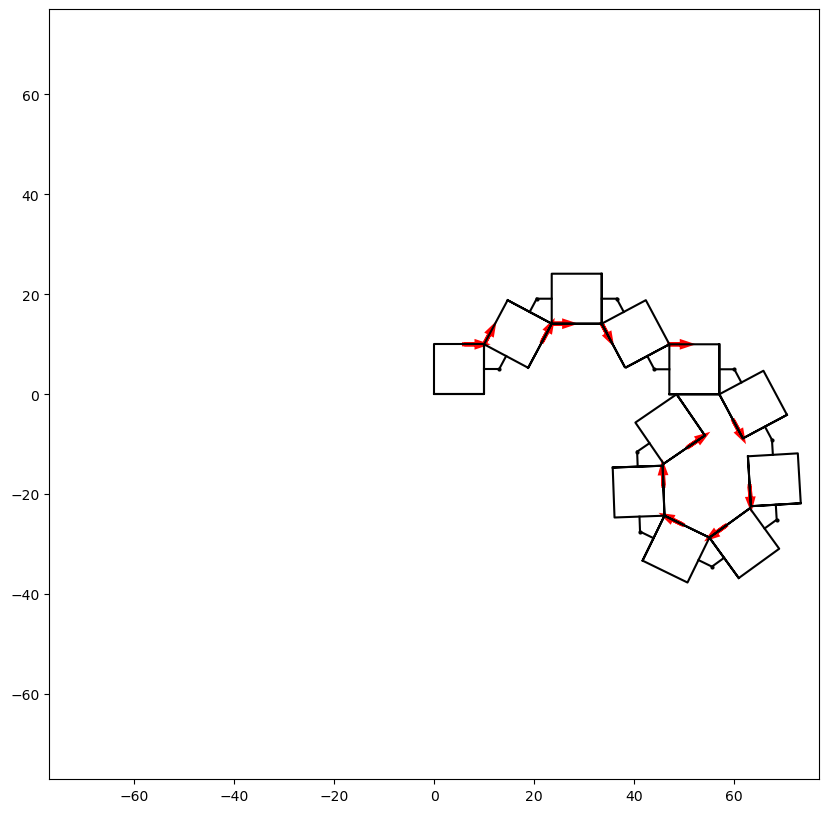

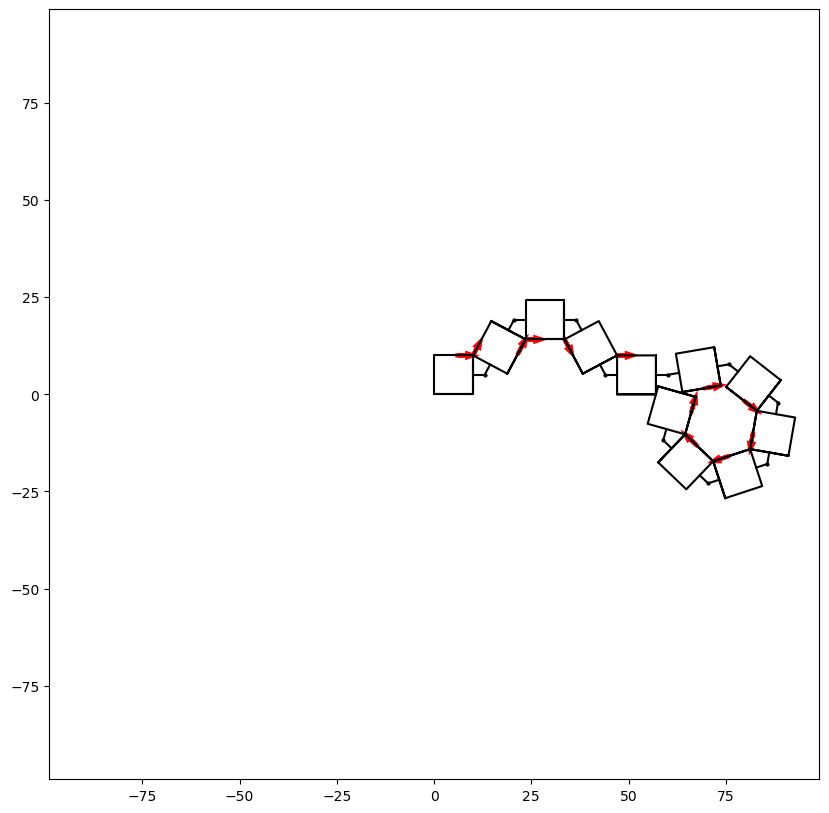

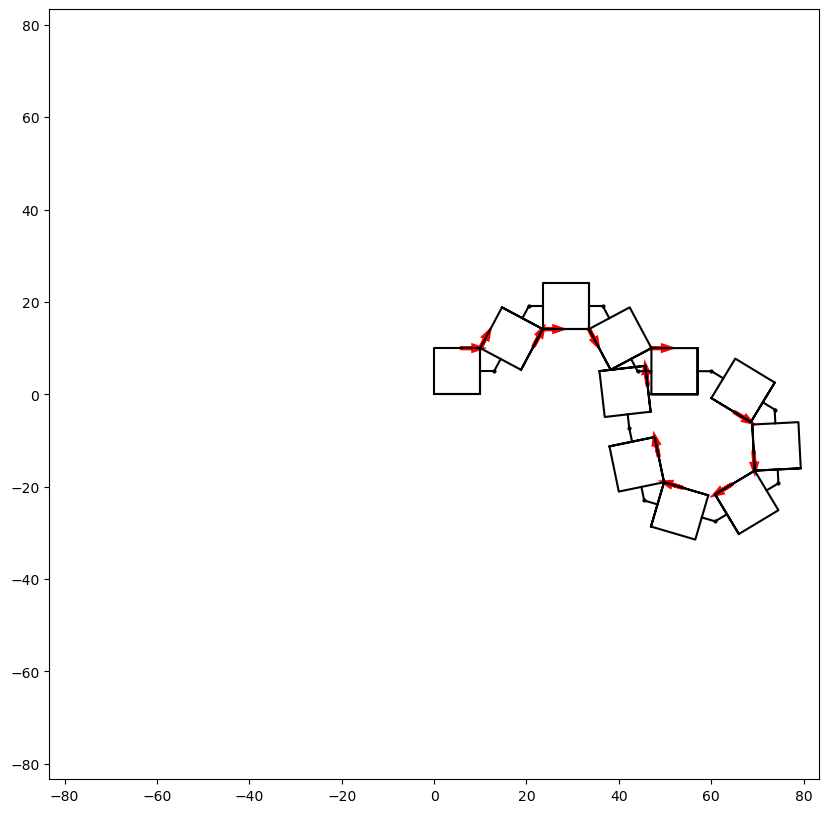

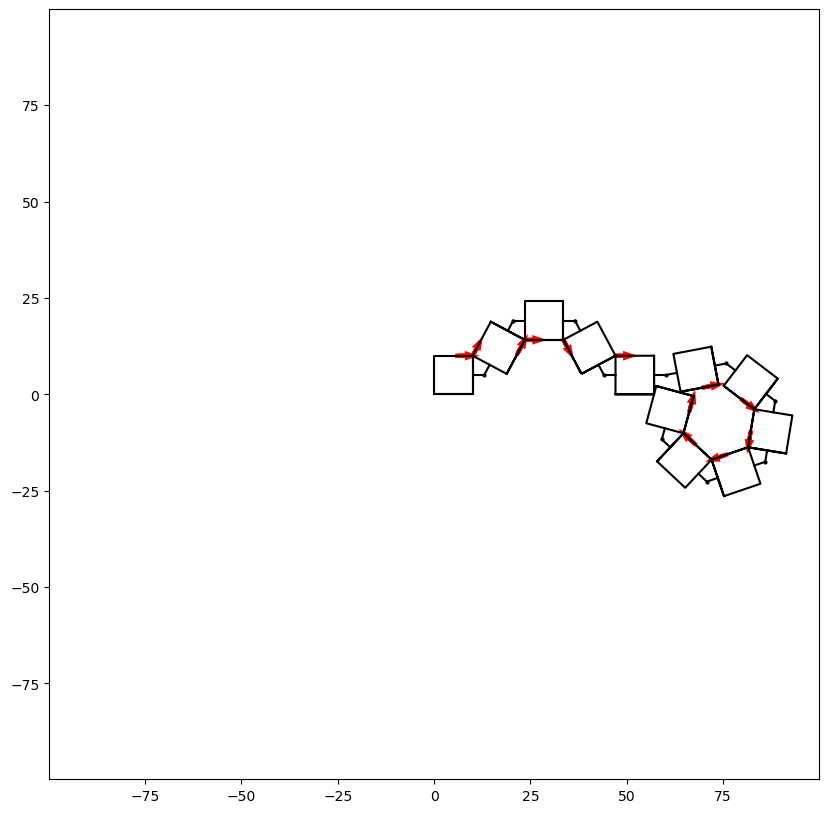

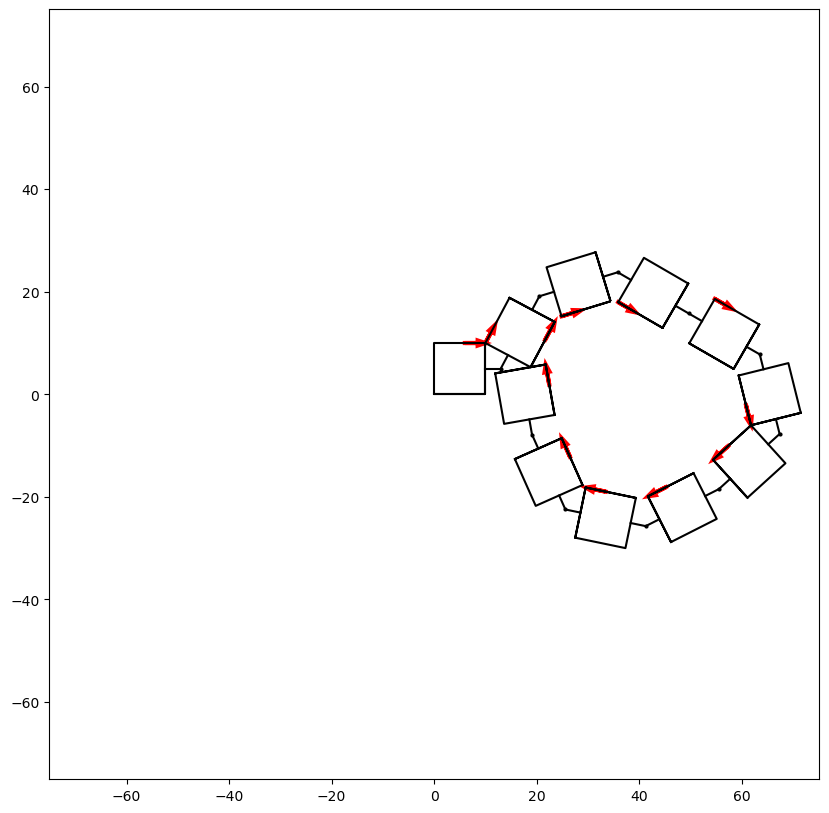

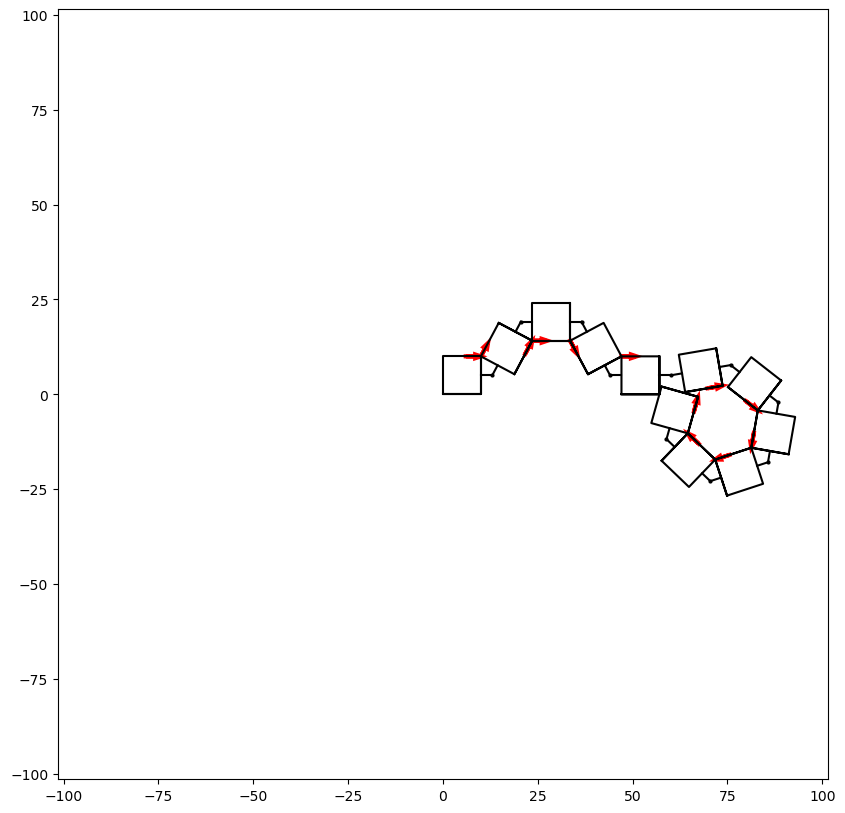

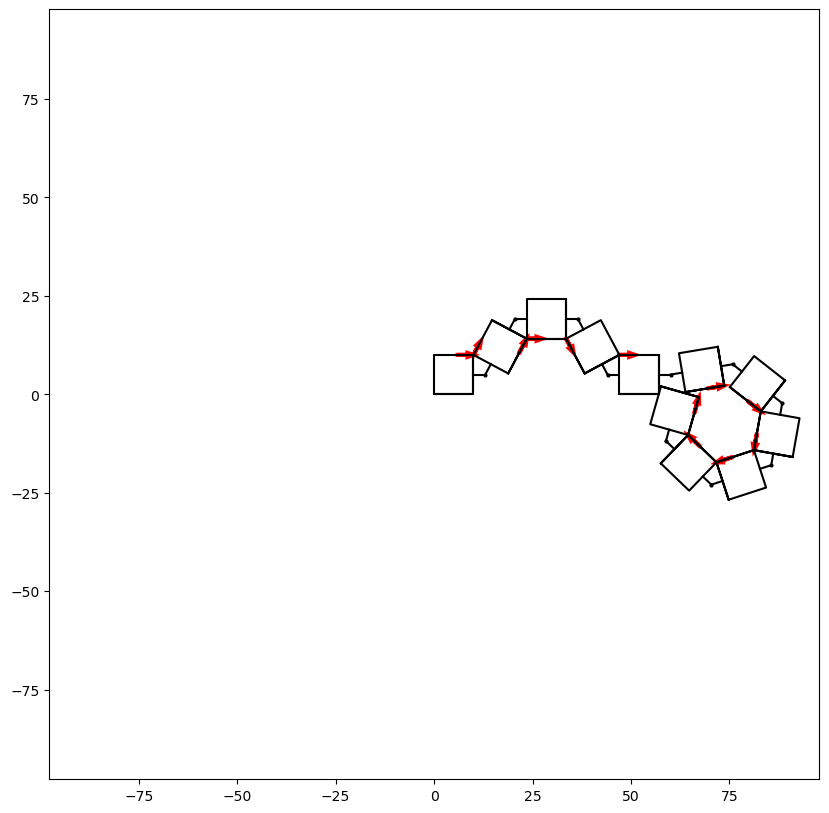

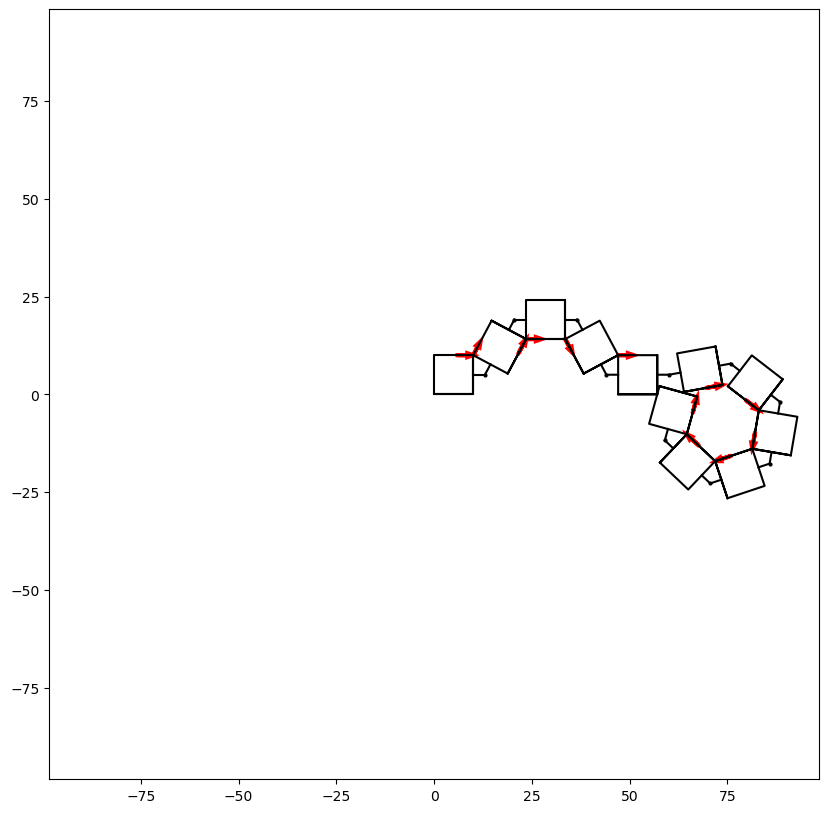

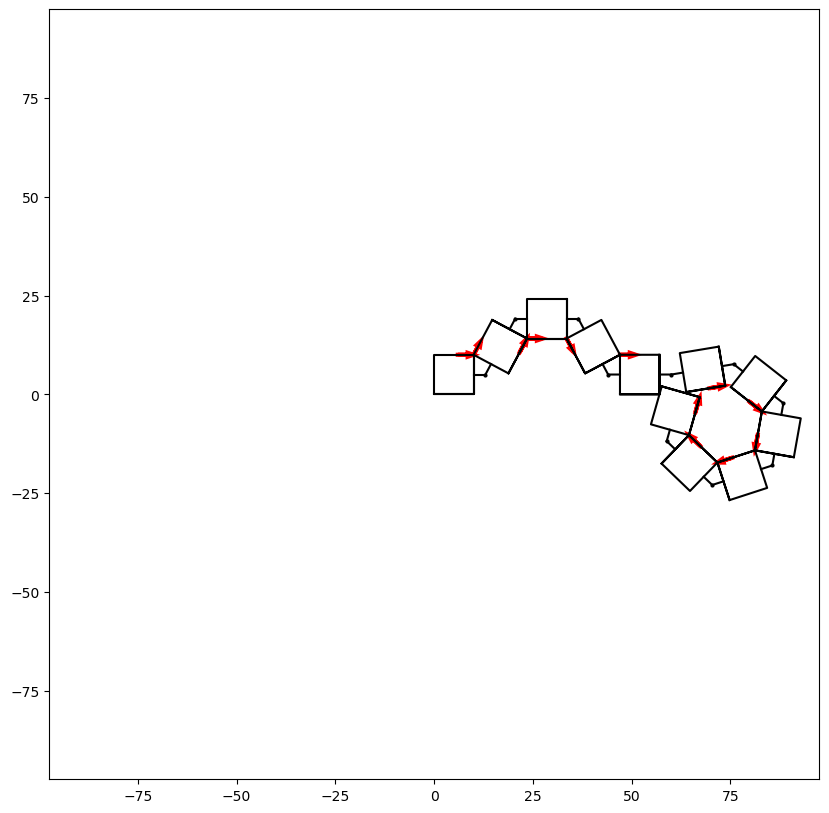

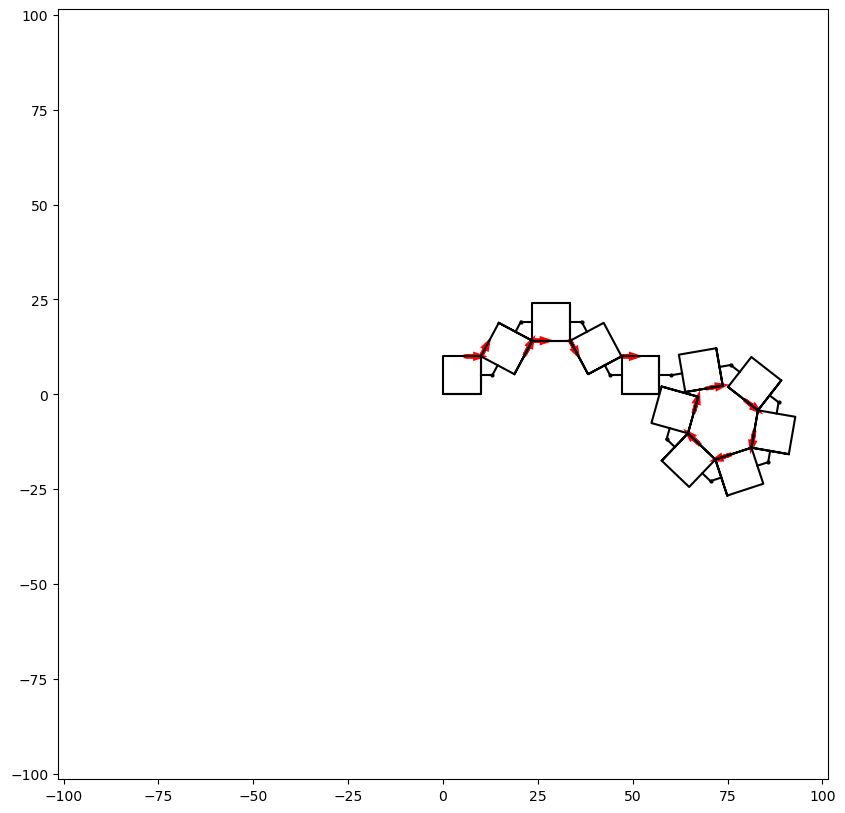

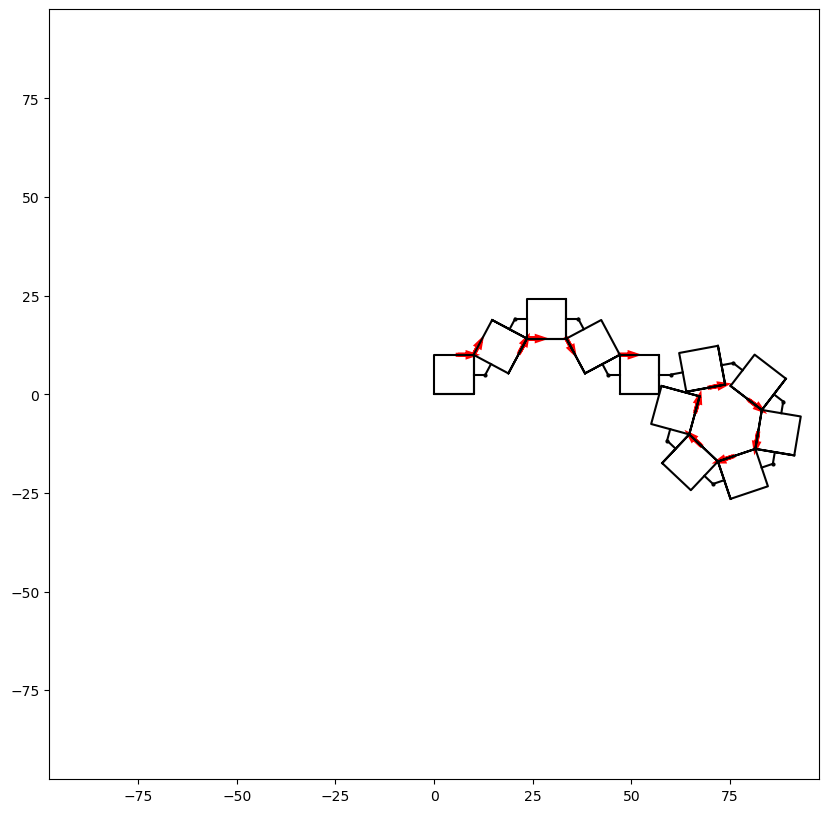

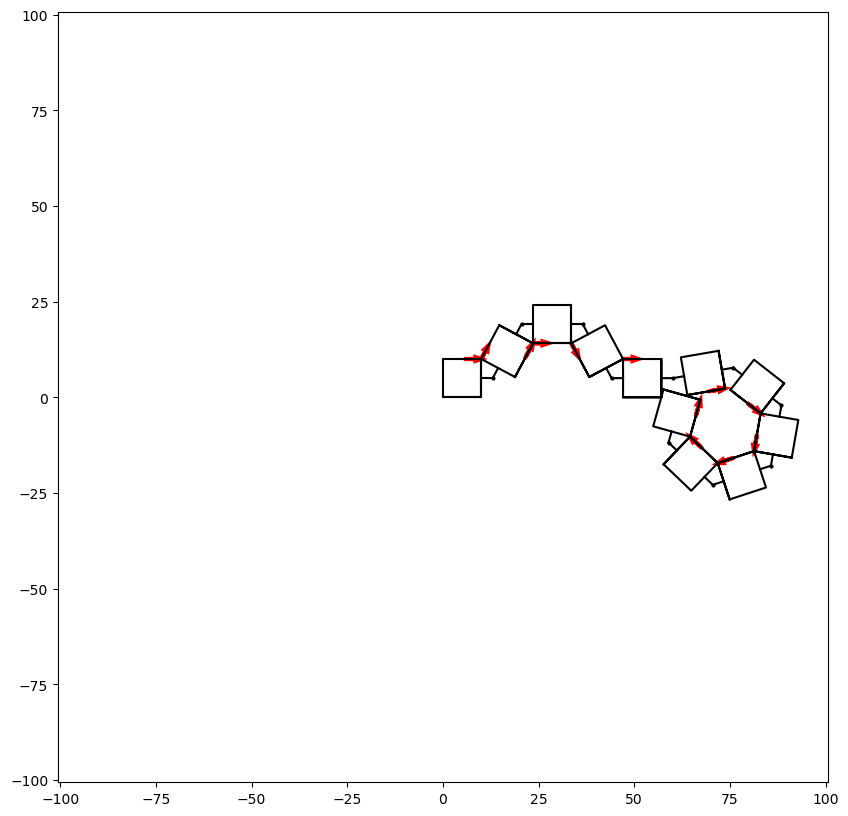

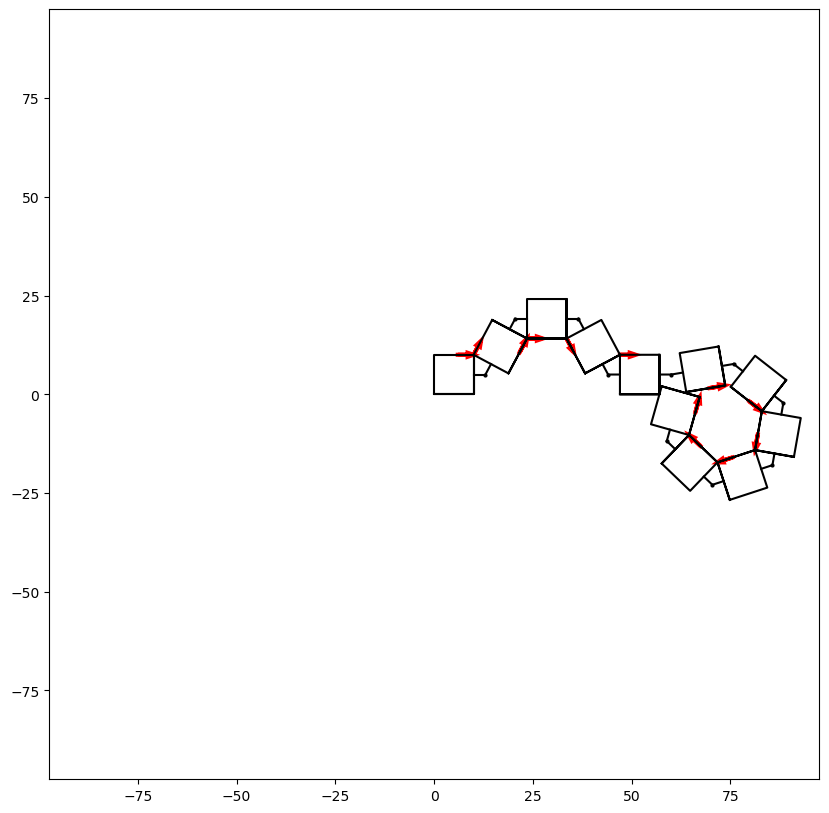

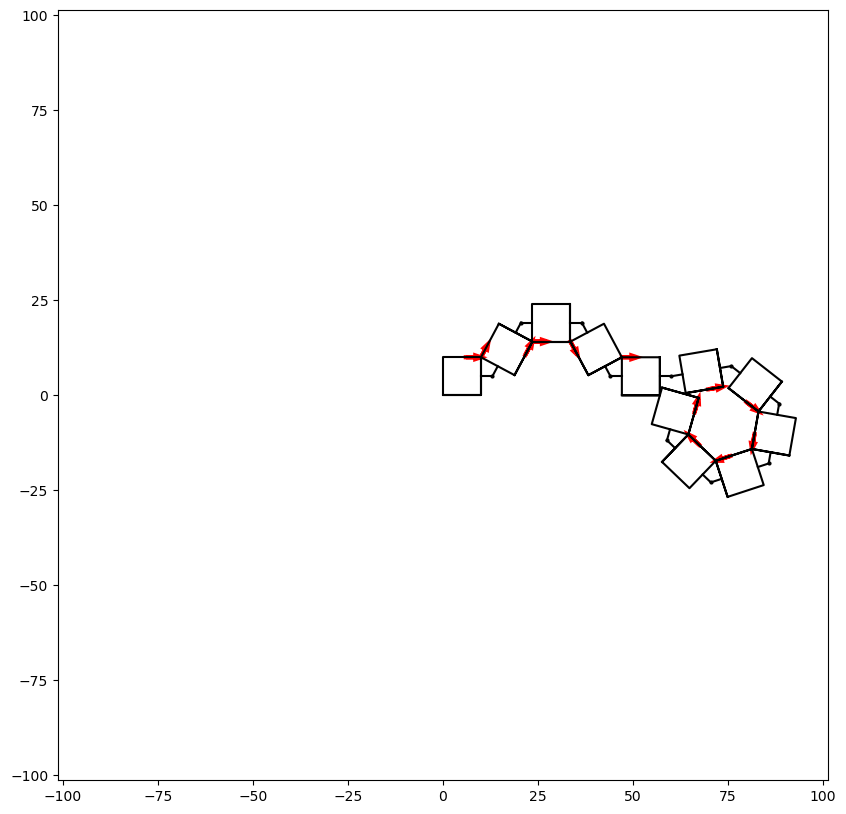

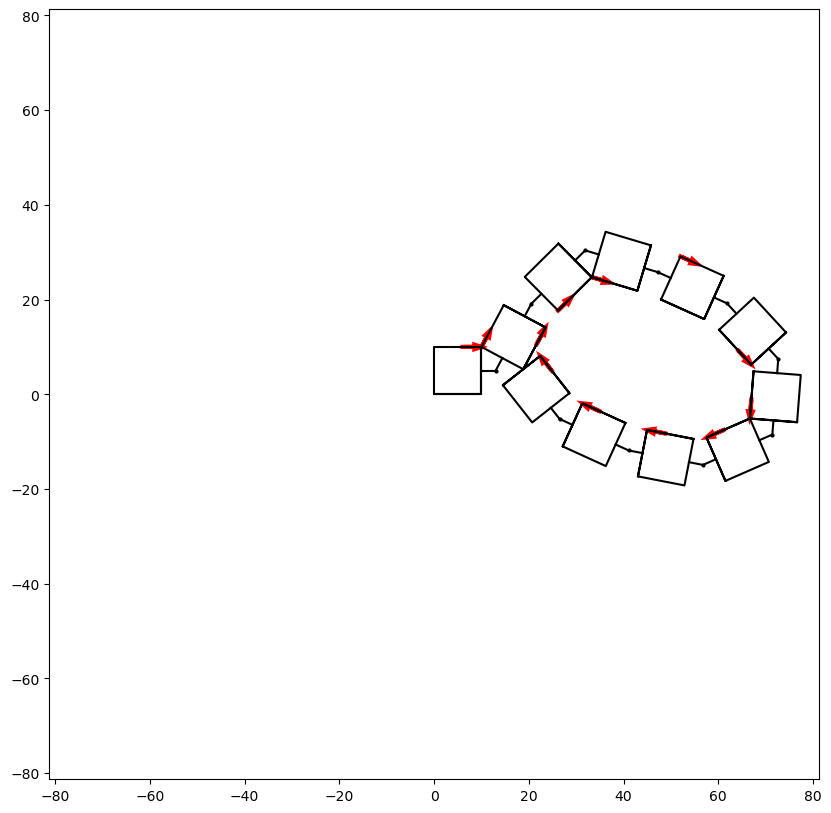

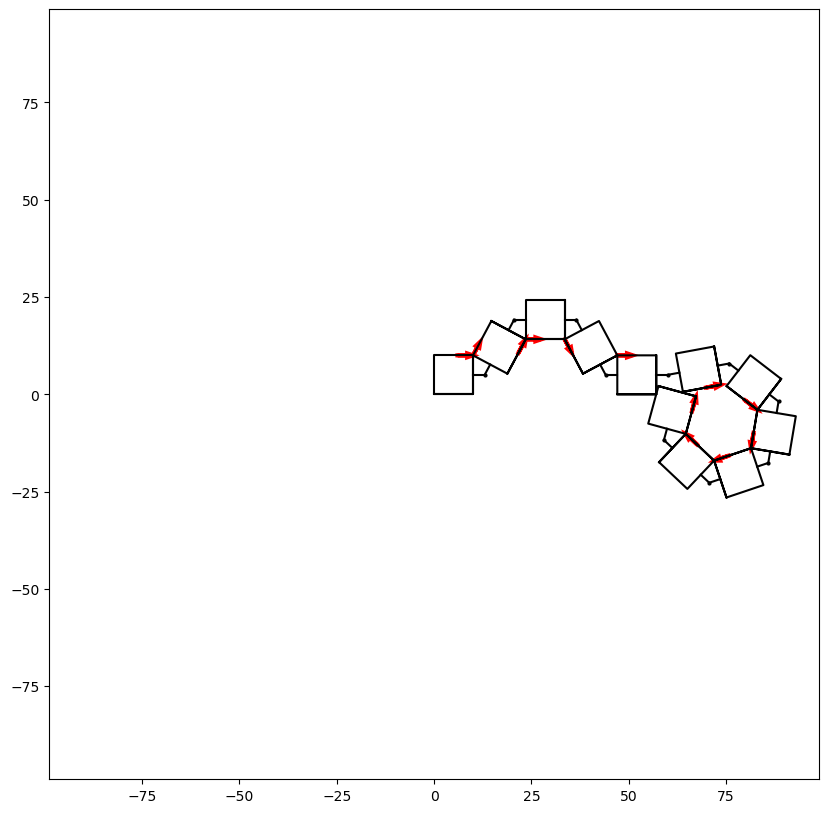

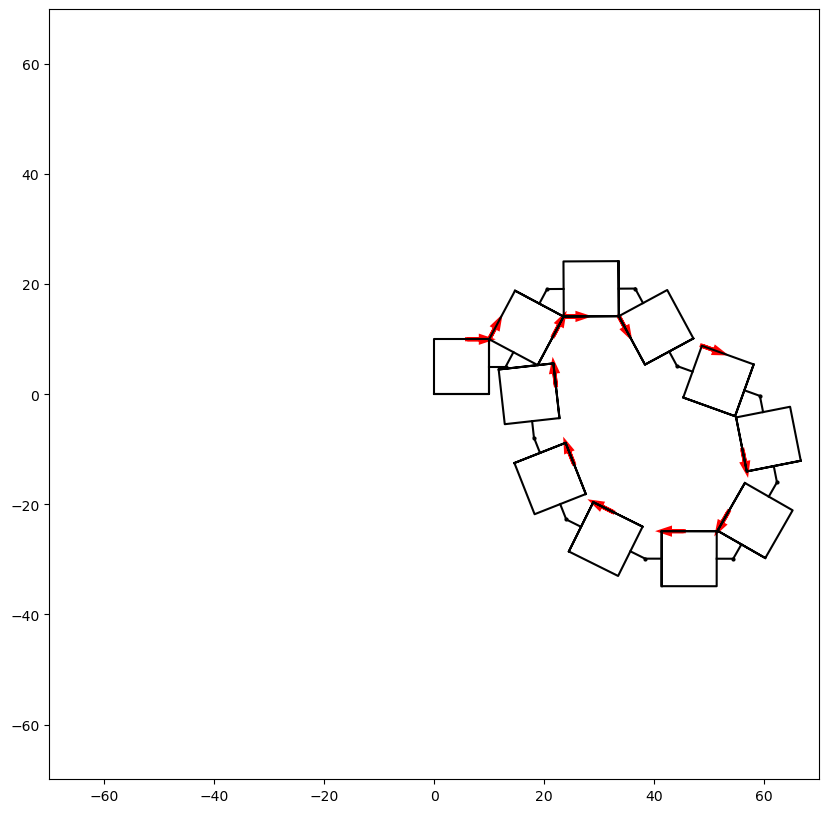

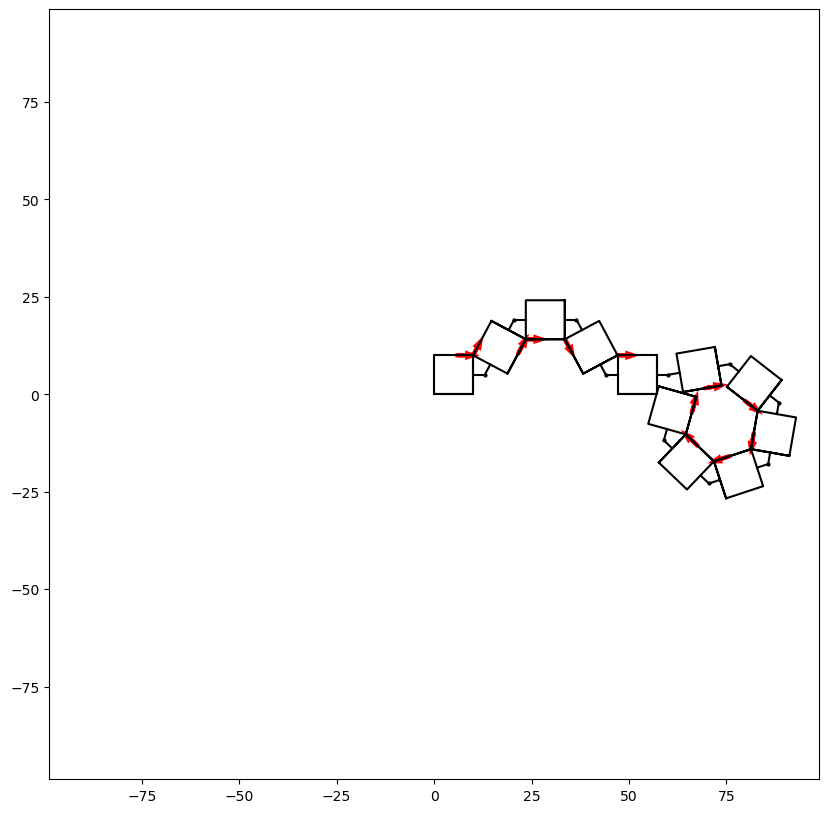

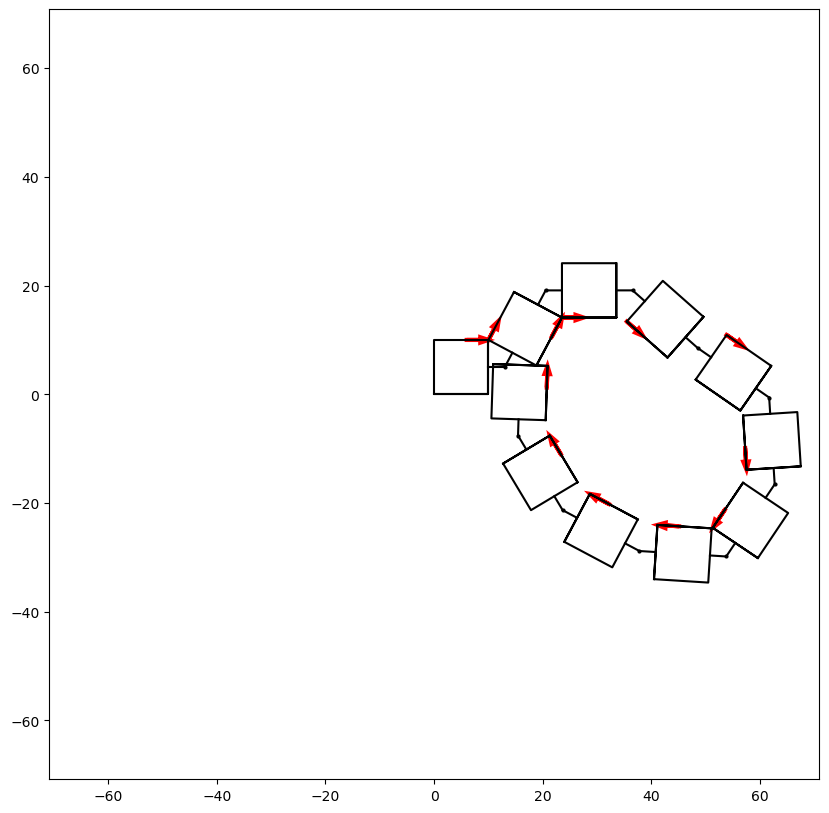

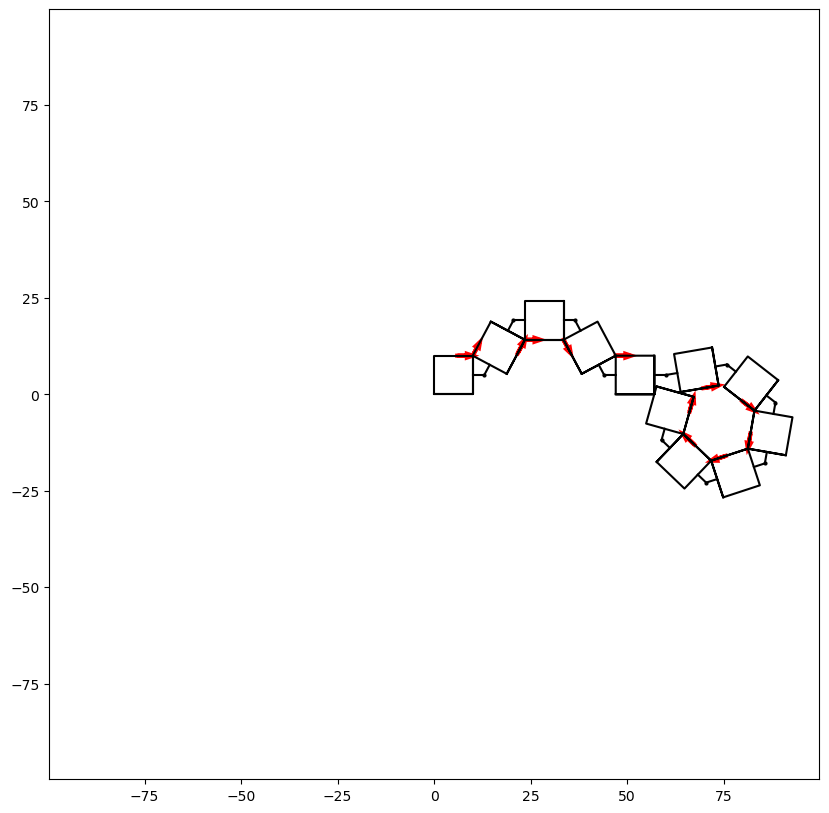

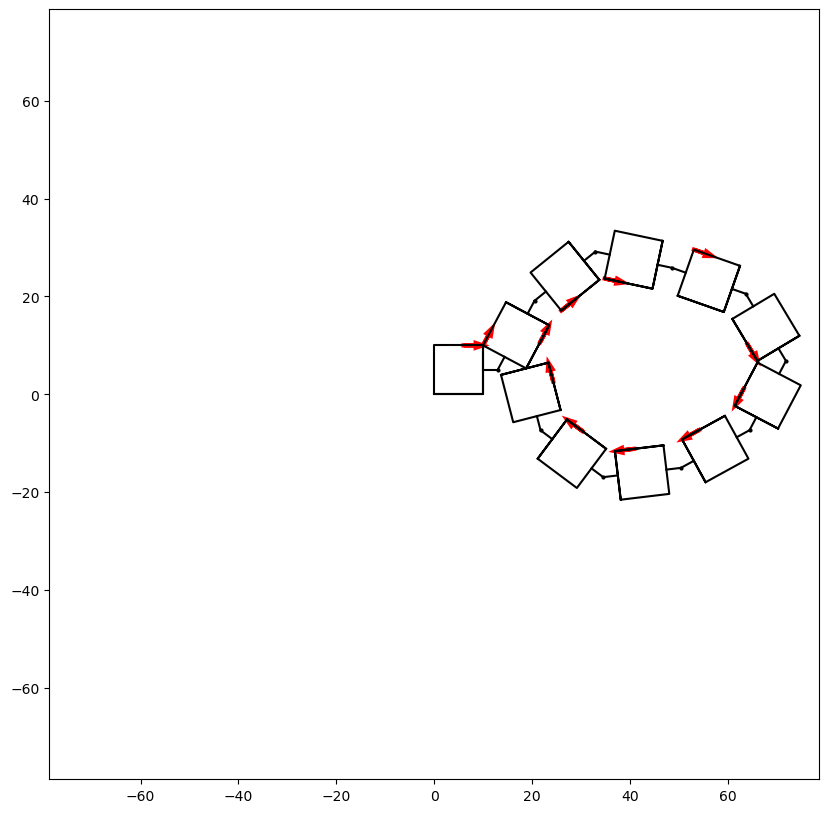

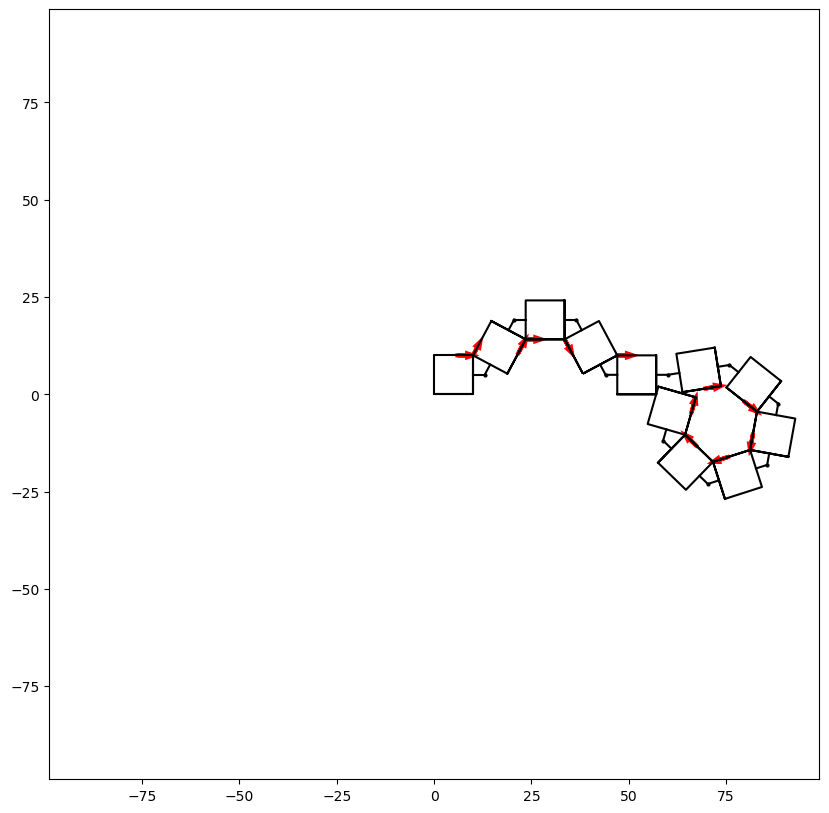

In [69]:
# running these tests many times
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
numsim = 20
energy_gdmc = [[] for _ in range(numsim)]
energy_gdws = [[] for _ in range(numsim)]
energy_mc = [[] for _ in range(numsim)]
energy_ws = [[] for _ in range(numsim)]
for i in range(numsim):
    patch_arr_mc, shape_arr_mc, hinge_vec_mc, hinge_loc_mc, current_energy_mc, energy_mc[i] = sim.simulate_monteCarlo(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter)
    patch_arr_ws, shape_arr_ws, hinge_vec_ws, hinge_loc_ws, current_energy_ws, energy_ws[i] = sim.simulate_weightedSync(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter)
    
    patch_arr_gdmc, shape_arr_gdmc, hinge_vec_gdmc, hinge_loc_gdmc, current_energy_gdmc, energy_gdmc[i] = sim.simulate_greedyDescent(patch_arr_mc,shape_arr_mc,linelist,hinge_vec_mc, hinge_loc_mc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, sim_num=1, ani_folder='tests')
    patch_arr_gdws, shape_arr_gdws, hinge_vec_gdws, hinge_loc_gdws, current_energy_gdws, energy_gdws[i] = sim.simulate_greedyDescent(patch_arr_ws,shape_arr_ws,linelist,hinge_vec_ws, hinge_loc_ws, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, animate=True, sim_num=2, ani_folder='tests')   
     

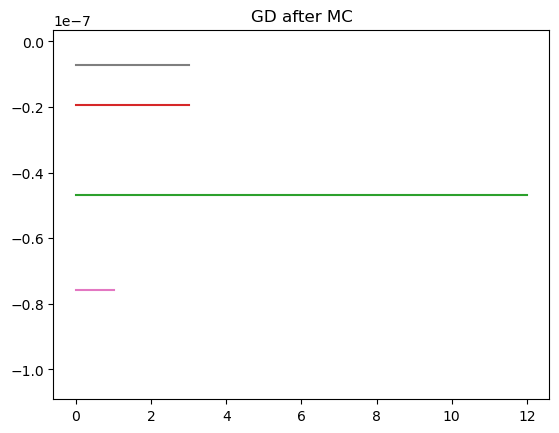

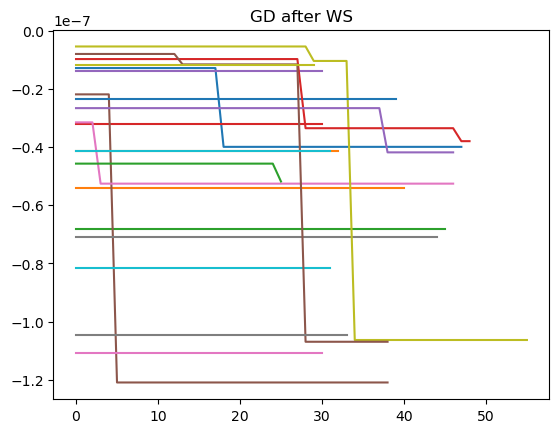

In [70]:
for i in range(numsim):
    plt.plot(energy_gdmc[i])
    plt.title("GD after MC")
plt.show()
for i in range(numsim):
    plt.plot(energy_gdws[i])
    plt.title("GD after WS")
plt.show()

In [17]:
energy_gdmc

[array([-1.00231626e-08]),
 array([-1.12969715e-08, -1.12969715e-08, -1.12969715e-08, -1.12969715e-08]),
 array([-2.94701654e-08]),
 array([-6.3617049e-09]),
 array([-2.74298555e-09, -1.66442583e-08]),
 array([-9.54668879e-09, -9.54668879e-09, -5.54449598e-08, -5.54449599e-08,
        -5.54449599e-08, -5.54449599e-08, -5.54449599e-08, -5.54449599e-08,
        -5.54449599e-08, -5.54449599e-08]),
 array([-1.56222237e-08]),
 array([-1.76433137e-08]),
 array([-5.16443711e-08]),
 array([-9.02226886e-09]),
 array([-4.79046451e-09]),
 array([-2.04019953e-07]),
 array([-7.05679484e-08]),
 array([-4.85016509e-09]),
 array([-3.75643612e-08]),
 array([-3.3104326e-08]),
 array([-1.31756002e-08, -2.07239705e-08]),
 array([-1.10969105e-07, -1.53948683e-07]),
 array([-1.09567096e-07]),
 array([-4.47233304e-09])]